# Creative VAE

A probabilistic framework for creative image generation between digit classes 2 and 6.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Education/CS\ 6501/Project

/content/drive/MyDrive/Education/CS 6501/Project


In [3]:
import copy
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, Subset, WeightedRandomSampler, TensorDataset
from torchvision import datasets, models, transforms
from typing import Literal, Optional, Sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


## Model

In [4]:
def he_initialization(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class VariationalAutoEncoder(nn.Module):
    def __init__(
        self,
        real_dim: int,
        h_dims: int | Sequence[int],
        bn_dim: int,
        activation: nn.Module = nn.ReLU(),
        decoder_type: Literal["gaussian", "bernoulli"] = "gaussian",
        initialize: bool = False,
    ):
        super().__init__()

        if isinstance(h_dims, int):
            h_dims = [h_dims]
        else:
            h_dims = list(h_dims)

        # ------- ENCODER -------
        encoder_shared_layers = []
        prev_dim = real_dim
        for h in h_dims:
            encoder_shared_layers.append(nn.Linear(prev_dim, h))
            encoder_shared_layers.append(type(activation)())
            prev_dim = h

        self.Encoder      = nn.Sequential(*encoder_shared_layers)
        self.mu_head      = nn.Linear(prev_dim, bn_dim)
        self.log_var_head = nn.Linear(prev_dim, bn_dim)  # outputs log sigma^2

        # ------- DECODER -------
        decoder_layers = []
        prev_dim = bn_dim
        for h in h_dims[::-1]:
            decoder_layers.append(nn.Linear(prev_dim, h))
            decoder_layers.append(type(activation)())
            prev_dim = h

        decoder_layers.append(nn.Linear(prev_dim, real_dim))
        decoder_layers.append(nn.Sigmoid())  # always sigmoid — outputs in [0, 1]
        self.Decoder = nn.Sequential(*decoder_layers)

        # ------- INITIALIZATIONS -------
        if initialize:
            self.apply(he_initialization)
            nn.init.xavier_uniform_(self.Decoder[-2].weight)
            nn.init.zeros_(self.Decoder[-2].bias)

    def encode(self, x: torch.Tensor):
        shared  = self.Encoder(x)
        mu      = self.mu_head(shared)
        log_var = self.log_var_head(shared)
        return mu, log_var

    def decode(self, z: torch.Tensor):
        return self.Decoder(z)

    def reparamaterize(self, mu: torch.Tensor, log_var: torch.Tensor):
        var = torch.exp(0.5 * log_var)
        eps = torch.randn_like(var)
        return mu + var * eps

    def forward(self, x: torch.Tensor):
        mu, log_var = self.encode(x)
        z           = self.reparamaterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var


def copy_vae(base_vae: nn.Module, device: torch.device) -> nn.Module:
    """
    Deep-copy a trained VAE so each creative experiment starts from identical
    weights without modifying the base or interfering with other copies.
    """
    return copy.deepcopy(base_vae).to(device)

## Metrics

The creativity score is a geometric mean of three components, all in $[0,1]$:

$$DC(x) = V(x)^{a_1} \cdot N(x)^{a_2} \cdot S(x,z)^{a_3} \quad \text{where} \quad \sum a_i = 1$$

In log space this becomes a weighted sum of log components, which is what we optimize during training.

In [5]:
def surprise(kl: torch.Tensor, lambda_s: float) -> torch.Tensor:
    """
    S(x, z) = 1 - exp(-lambda * KL)

    Normalizes KL from [0, inf) into [0, 1). lambda_s controls how quickly
    S saturates — calibrate so S ~ 0.5-0.8 at the warmup KL equilibrium.
    """
    kl_clamped = torch.clamp(kl, min=1e-8)
    return 1 - torch.exp(-lambda_s * kl_clamped)


def novelty(
    x_hat: torch.Tensor,
    digit_classifier: nn.Module,
    c1: int = 2,
    c2: int = 6,
    eps: float = 1e-8,
    ambiguity_weight: float = 0.7,
    relevance_weight: float = 0.3,
) -> torch.Tensor:

    x_hat = x_hat.view(-1, 1, 28, 28)
    probs = F.softmax(digit_classifier(x_hat), dim=1)  # (B, 10)

    p_c1 = probs[:, c1]                                # (B,)
    p_c2 = probs[:, c2]                                # (B,)
    relevance = p_c1 + p_c2                            # (B,)

    # renormalize over {c1, c2} to isolate ambiguity between them
    p_tilde_c1 = p_c1 / (relevance + eps)
    p_tilde_c2 = p_c2 / (relevance + eps)

    # binary entropy normalized to [0, 1]
    h = -(
        p_tilde_c1 * torch.log(p_tilde_c1 + eps)
        + p_tilde_c2 * torch.log(p_tilde_c2 + eps)
    ) / torch.log(torch.tensor(2.0, device=x_hat.device))  # (B,)

    # geometric mean — non-compensatory, ambiguity-weighted
    n = h ** ambiguity_weight * relevance ** relevance_weight

    return n.mean()  # scalar in [0, 1]


def value(
    x_hat: torch.Tensor,
    digit_vs_nondigit_classifier: nn.Module,
    eps: float = 1e-8,
    emnist_mu: float = 0,
    emnist_sd: float = 1,
) -> torch.Tensor:

    x_hat  = x_hat.view(-1, 1, 28, 28)
    x_norm = (x_hat - emnist_mu) / emnist_sd

    logits  = digit_vs_nondigit_classifier(x_norm)  # (B, 1)
    p_digit = torch.sigmoid(logits.squeeze(1))       # (B,)

    return p_digit.mean()  # scalar in [0, 1]


def log_creativity_score(
    x_hat: torch.Tensor,
    kl: torch.Tensor,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    value_weight: float,
    novelty_weight: float,
    surprise_weight: float,
    lambda_s: float,
    c1: int = 2,
    c2: int = 6,
    eps: float = 1e-8,
    log_means: Optional[dict] = None,
    log_stds: Optional[dict] = None,
) -> tuple:
    """
    Compute log DC = a1*log(V) + a2*log(N) + a3*log(S) — the training objective.

    When log_means and log_stds are provided (from creativity_diagnostic), each
    log component is z-score standardized before weighting. This ensures the weights
    a1, a2, a3 have consistent influence regardless of each component's raw variance.
    Z-scores are clamped to [-3, 3] to prevent gradient explosion.

    Returns:
        (log_dc, log_v, log_n, log_s, v, n, s)
        log_dc — training signal (standardized weighted sum)
        v, n, s — raw scores in [0, 1] for monitoring
    """
    v = value(x_hat, value_classifier, eps)
    n = novelty(x_hat, digit_classifier, c1, c2, eps)
    s = surprise(kl, lambda_s)

    log_v = torch.log(v + eps)
    log_n = torch.log(n + eps)
    log_s = torch.log(s + eps)

    if log_means is not None and log_stds is not None:
        log_v = torch.clamp((log_v - log_means["V"]) / (log_stds["V"] + eps), -3, 3)
        log_n = torch.clamp((log_n - log_means["N"]) / (log_stds["N"] + eps), -3, 3)
        log_s = torch.clamp((log_s - log_means["S"]) / (log_stds["S"] + eps), -3, 3)

    log_dc = value_weight * log_v + novelty_weight * log_n + surprise_weight * log_s

    return log_dc, log_v, log_n, log_s, v, n, s

In [6]:
def ELBO(
    pred: Sequence[torch.Tensor],
    x: torch.Tensor,
    decoder_dist: Literal["gaussian", "bernoulli"],
):
    """
    Compute ELBO components (reconstruction, kl). Both are scalars.

    Reconstruction is summed over pixels then averaged over the batch —
    this keeps it on the same scale as KL and prevents posterior collapse,
    which occurs when using F.mse_loss or F.binary_cross_entropy with
    reduction='mean' (which divides by both batch size and pixel count).
    """
    x_hat, mu, log_var = pred

    kl = -0.5 * (1 + log_var - mu ** 2 - torch.exp(log_var)).sum(dim=1).mean()

    if decoder_dist == "bernoulli":
        x_hat = x_hat.clamp(1e-8, 1 - 1e-8)
        reconstruction = (
            x * x_hat.log() + (1 - x) * (1 - x_hat).log()
        ).sum(dim=1).mean()

    elif decoder_dist == "gaussian":
        reconstruction = -0.5 * ((x - x_hat) ** 2).sum(dim=1).mean()

    return reconstruction, kl

## Classifiers & Data

### Functions

In [7]:
def build_value_classifier() -> nn.Module:
    """ResNet18 adapted for 1-channel 28x28 input with binary output."""
    model       = models.resnet18()
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.fc    = nn.Linear(512, 1)
    return model


def build_digit_classifier() -> nn.Module:
    """10-class CNN trained on MNIST with MixUp for better calibration near class boundaries."""
    return nn.Sequential(
        nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=1),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
        nn.Dropout(0.2),
        nn.Flatten(),
        nn.Linear(64 * 676, 10),
    )


def load_classifiers(
    value_path: str,
    digit_path: str,
    device: torch.device,
) -> tuple[nn.Module, nn.Module]:
    """
    Load pretrained classifiers, freeze their weights, and move to device.

    Frozen with requires_grad_(False) on parameters — NOT torch.no_grad() —
    so gradients still flow through the classifiers into x_hat during the
    creative training backward pass.

    Returns:
        (digit_classifier, value_classifier)
    """
    value_clf = build_value_classifier()
    value_clf.load_state_dict(torch.load(value_path, map_location=device))
    value_clf.to(device).eval()
    for p in value_clf.parameters():
        p.requires_grad_(False)

    digit_clf = build_digit_classifier()
    digit_clf.load_state_dict(torch.load(digit_path, map_location=device))
    digit_clf.to(device).eval()
    for p in digit_clf.parameters():
        p.requires_grad_(False)

    return digit_clf, value_clf


def get_dataloaders(batch_size: int = 256) -> tuple[DataLoader, DataLoader]:
    """
    MNIST train and test loaders filtered to digits 2 and 6 only.

    No normalization applied here — the MNIST digit classifier was trained on
    raw [0, 1] pixel values. EMNIST normalization for the value classifier is
    applied inside value() at call time.
    """
    transform_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    ])
    transform_test = transforms.ToTensor()

    train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform_train)
    test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform_test)

    twos_train  = Subset(train_dataset, (train_dataset.targets == 2).nonzero(as_tuple=True)[0])
    sixes_train = Subset(train_dataset, (train_dataset.targets == 6).nonzero(as_tuple=True)[0])
    twos_test   = Subset(test_dataset,  (test_dataset.targets  == 2).nonzero(as_tuple=True)[0])
    sixes_test  = Subset(test_dataset,  (test_dataset.targets  == 6).nonzero(as_tuple=True)[0])

    train_loader = DataLoader(
        ConcatDataset([twos_train, sixes_train]),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        ConcatDataset([twos_test, sixes_test]),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )

    return train_loader, test_loader

### Training Value Classifier

In [8]:
from torch.utils.data import ConcatDataset, DataLoader, Subset, TensorDataset, WeightedRandomSampler

def train_value_classifier(
    vae: nn.Module,
    epochs: int = 10,
    batch_size: int = 256,
    lr: float = 1e-3,
    latent_dim: int = 32,
    n_vae_samples: int = 50,
    device: torch.device = torch.device("cpu"),
    save_path: str = "models/value_clf.pth",
) -> nn.Module:
    """
    Train the binary digit-vs-letter classifier on EMNIST Balanced + MNIST + VAE samples.

    Label convention: 1 = digit, 0 = letter, consistent with
    sigmoid(logit) = P(digit|x) in value().

    Three positive sources:
      - EMNIST Balanced digits: broad handwriting style coverage
      - MNIST digits: closes domain gap to the VAE's training distribution
      - VAE prior samples: closes domain gap to the blurry Bernoulli decoder
        outputs seen at inference time during creative training

    EMNIST letters serve as negative examples. Uniform noise (20% per batch)
    prevents OOD overconfidence. WeightedRandomSampler balances digit vs letter
    since EMNIST Balanced has ~3.7x more letter samples than digit samples.

    EMNIST images are transposed relative to MNIST — permute(0,2,1).flip(1)
    corrects orientation before training. All datasets are converted to
    TensorDatasets for consistent collation in the DataLoader.
    """
    # ── EMNIST ────────────────────────────────────────────────────
    emnist_train = datasets.EMNIST(
        root="./data", split="balanced", train=True, download=True,
    )
    emnist_test = datasets.EMNIST(
        root="./data", split="balanced", train=False, download=True,
    )

    # fix EMNIST orientation to match MNIST
    emnist_train.data = emnist_train.data.permute(0, 2, 1).flip(1)
    emnist_test.data  = emnist_test.data.permute(0, 2, 1).flip(1)

    # remap: digit classes 0-9 → label 1, letter classes 10-46 → label 0
    emnist_train.targets = (emnist_train.targets < 10).long()
    emnist_test.targets  = (emnist_test.targets  < 10).long()

    emnist_train_td = TensorDataset(
        emnist_train.data.unsqueeze(1).float() / 255.0,
        emnist_train.targets,
    )
    emnist_test_td = TensorDataset(
        emnist_test.data.unsqueeze(1).float() / 255.0,
        emnist_test.targets,
    )

    # ── MNIST ─────────────────────────────────────────────────────
    mnist_train = datasets.MNIST(root="./data", train=True,  download=True)
    mnist_test  = datasets.MNIST(root="./data", train=False, download=True)

    mnist_train_targets = torch.ones(len(mnist_train), dtype=torch.long)
    mnist_test_targets  = torch.ones(len(mnist_test),  dtype=torch.long)

    mnist_train_td = TensorDataset(
        mnist_train.data.unsqueeze(1).float() / 255.0,
        mnist_train_targets,
    )
    mnist_test_td = TensorDataset(
        mnist_test.data.unsqueeze(1).float() / 255.0,
        mnist_test_targets,
    )

    # ── VAE prior samples ──────────────────────────────────────────
    # Closes the domain gap between crisp EMNIST/MNIST digits and the
    # blurry Bernoulli decoder outputs seen at inference time.
    vae.eval()
    vae_samples = []
    with torch.no_grad():
        for _ in range(0, n_vae_samples, batch_size):
            z = torch.randn(batch_size, latent_dim, device=device)
            x = vae.decode(z).view(batch_size, 1, 28, 28).cpu()
            vae_samples.append(x)
    vae_samples = torch.cat(vae_samples)[:n_vae_samples]
    vae_labels  = torch.ones(n_vae_samples, dtype=torch.long)
    vae_dataset = TensorDataset(vae_samples, vae_labels)

    # ── combine ───────────────────────────────────────────────────
    train_dataset = ConcatDataset([emnist_train_td, mnist_train_td, vae_dataset])
    test_dataset  = ConcatDataset([emnist_test_td,  mnist_test_td])

    # ── weighted sampler to balance digit vs letter ────────────────
    all_targets = torch.cat([
        emnist_train.targets,
        mnist_train_targets,
        vae_labels,
    ])
    n_digit        = (all_targets == 1).sum().item()
    n_letter       = (all_targets == 0).sum().item()
    class_weight   = {1: 1.0 / n_digit, 0: 1.0 / n_letter}
    sample_weights = torch.tensor([class_weight[t.item()] for t in all_targets])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True),
        num_workers=2,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    model     = build_value_classifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    noise_fraction = 0.2

    print("\n── Value Classifier Training ───────────────────────────────")
    for epoch in range(epochs):
        model.train()
        train_loss = train_correct = train_total = 0

        for x, y in train_loader:
            x = x.to(device)          # (B, 1, 28, 28), raw [0, 1]
            y = y.float().to(device)  # (B,) — 1=digit, 0=letter

            # replace a fraction of the batch with uniform noise,
            # labelled as non-digit (0)
            n_noise = int(noise_fraction * x.size(0))
            if n_noise > 0:
                x[:n_noise] = torch.rand(n_noise, 1, 28, 28, device=device)
                y[:n_noise] = 0.0

            optimizer.zero_grad()
            logits = model(x).squeeze(1)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            preds          = (torch.sigmoid(logits) > 0.5).long()
            train_correct += (preds == y.long()).sum().item()
            train_total   += y.size(0)
            train_loss    += loss.item()

        # ── eval ──────────────────────────────────────────────────
        model.eval()
        test_loss = test_correct = test_total = 0
        digit_correct = digit_total = letter_correct = letter_total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x      = x.to(device)
                y      = y.float().to(device)
                logits = model(x).squeeze(1)
                test_loss += criterion(logits, y).item()

                preds  = (torch.sigmoid(logits) > 0.5).long()
                y_long = y.long()

                test_correct += (preds == y_long).sum().item()
                test_total   += y_long.size(0)

                digit_mask     = y_long == 1
                letter_mask    = y_long == 0
                digit_correct  += (preds[digit_mask]  == y_long[digit_mask]).sum().item()
                digit_total    += digit_mask.sum().item()
                letter_correct += (preds[letter_mask] == y_long[letter_mask]).sum().item()
                letter_total   += letter_mask.sum().item()

        n_tr = len(train_loader)
        n_te = len(test_loader)
        print(
            f"Epoch {epoch + 1}/{epochs}"
            f"  train loss={train_loss/n_tr:.4f}  acc={train_correct/train_total:.4f}"
            f"  test  loss={test_loss/n_te:.4f}  acc={test_correct/test_total:.4f}"
            f"  digit acc={digit_correct/digit_total:.4f}"
            f"  letter acc={letter_correct/letter_total:.4f}"
        )

    torch.save(model.state_dict(), save_path)
    print(f"Saved → {save_path}")
    return model

In [9]:
# value_clf = train_value_classifier(base_vae, 5, 256, device=device, save_path="models/value_clf.pth")

## Creativity Diagnostic

Run after warmup to collect V, N, S statistics from prior samples. Used to calibrate z-score standardization for creative training. Always returns the stats dict — `rescaling_needed` indicates whether standardization is recommended.

In [10]:
def creativity_diagnostic(
    vae: nn.Module,
    train_loader: DataLoader,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    lambda_s: float = 1.0,
    c1: int = 2,
    c2: int = 6,
    n_batches: int = 50,
    device: torch.device = torch.device("cpu"),
) -> dict:
    """
    Collect V, N, S statistics by scoring prior samples from the trained VAE.

    Scores prior samples (not reconstructions) to be consistent with the
    score_generated=True setting used during creative training.

    Always returns the full stats dict. The 'rescaling_needed' key indicates
    whether z-score standardization is recommended. Pass log_means and log_stds
    from the returned dict to log_creativity_score to enable standardization.
    """
    vae.eval()
    digit_classifier.eval()
    value_classifier.eval()

    all_v, all_n, all_s         = [], [], []
    all_log_v, all_log_n, all_log_s = [], [], []
    eps = 1e-8

    with torch.no_grad():
        for i, (x, _) in enumerate(train_loader):
            if i >= n_batches:
                break

            x      = x.to(device)
            x_flat = x.view(x.size(0), -1)

            x_hat, mu, log_var = vae(x_flat)
            kl = -0.5 * (1 + log_var - mu ** 2 - log_var.exp()).sum(dim=1).mean()

            # score prior samples — consistent with score_generated=True
            z_sample    = torch.randn_like(mu)
            x_generated = vae.decode(z_sample)

            v = value(x_generated,   value_classifier, eps)
            n = novelty(x_generated, digit_classifier, c1, c2, eps)
            s = surprise(kl,         lambda_s)

            log_v = torch.log(v + eps)
            log_n = torch.log(n + eps)
            log_s = torch.log(s + eps)

            all_v.append(v.item());     all_n.append(n.item());     all_s.append(s.item())
            all_log_v.append(log_v.item()); all_log_n.append(log_n.item()); all_log_s.append(log_s.item())

    V     = np.array(all_v);     N     = np.array(all_n);     S     = np.array(all_s)
    log_V = np.array(all_log_v); log_N = np.array(all_log_n); log_S = np.array(all_log_s)

    raw    = np.stack([V, N, S],         axis=1)
    logged = np.stack([log_V, log_N, log_S], axis=1)
    raw_corr = np.corrcoef(raw.T)
    log_corr = np.corrcoef(logged.T)
    labels   = ["V", "N", "S"]

    log_stds      = np.array([log_V.std(), log_N.std(), log_S.std()])
    log_var_share = log_stds / (log_stds.sum() + eps)

    print("=" * 60)
    print("CREATIVITY DIAGNOSTIC")
    print("=" * 60)

    print("\n── Raw scores ──────────────────────────────────────────────")
    print(f"{'':>6}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}")
    for label, arr in zip(labels, [V, N, S]):
        print(f"{label:>6}  {arr.mean():8.4f}  {arr.std():8.4f}  {arr.min():8.4f}  {arr.max():8.4f}")

    print("\n── Log scores ──────────────────────────────────────────────")
    print(f"{'':>6}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}")
    for label, arr in zip(labels, [log_V, log_N, log_S]):
        print(f"{label:>6}  {arr.mean():8.4f}  {arr.std():8.4f}  {arr.min():8.4f}  {arr.max():8.4f}")

    print("\n── Raw correlation matrix ──────────────────────────────────")
    print(f"{'':>8}", "".join(f"{l:>10}" for l in labels))
    for i, label in enumerate(labels):
        print(f"{label:>8}", "".join(f"{raw_corr[i,j]:10.4f}" for j in range(3)))

    print("\n── Log correlation matrix ──────────────────────────────────")
    print(f"{'':>8}", "".join(f"{l:>10}" for l in labels))
    for i, label in enumerate(labels):
        print(f"{label:>8}", "".join(f"{log_corr[i,j]:10.4f}" for j in range(3)))

    print("\n── Log score variance share ────────────────────────────────")
    print("  (how much each component contributes to total log DC variance)")
    for label, share, std in zip(labels, log_var_share, log_stds):
        print(f"  {label}: {share*100:.1f}%  (std={std:.4f})")

    print("\n── Recommendations ─────────────────────────────────────────")

    high_corr_pairs = [
        (labels[i], labels[j], log_corr[i, j])
        for i in range(3)
        for j in range(i + 1, 3)
        if abs(log_corr[i, j]) > 0.7
    ]
    if high_corr_pairs:
        for a, b, r in high_corr_pairs:
            print(f"  ⚠  {a} and {b} are highly correlated (r={r:.3f})")
    else:
        print("  ✓  No high correlations between components (all |r| < 0.7)")

    rescaling_needed = (log_var_share.max() / (log_var_share.min() + eps)) > 3.0
    dominant = labels[log_var_share.argmax()]
    weak     = labels[log_var_share.argmin()]

    if rescaling_needed:
        print(f"  ⚠  {dominant} dominates variance ({log_var_share.max()*100:.1f}%), "
              f"{weak} is weak ({log_var_share.min()*100:.1f}%) "
              f"— z-score rescaling applied")
    else:
        print("  ✓  Variance is reasonably balanced — z-score rescaling not needed")

    print("=" * 60)

    return {
        "means":            dict(zip(labels, [V.mean(),     N.mean(),     S.mean()])),
        "stds":             dict(zip(labels, [V.std(),      N.std(),      S.std()])),
        "log_means":        dict(zip(labels, [log_V.mean(), log_N.mean(), log_S.mean()])),
        "log_stds":         dict(zip(labels, [log_V.std(),  log_N.std(),  log_S.std()])),
        "raw_corr":         raw_corr,
        "log_corr":         log_corr,
        "log_var_share":    dict(zip(labels, log_var_share)),
        "rescaling_needed": rescaling_needed,
    }

## Plot Helpers

In [11]:
def _save_recon_plot(
    vae: nn.Module,
    fixed_x: torch.Tensor,
    fixed_x_flat: torch.Tensor,
    epoch: int,
    total_epochs: int,
    phase: str,
    img_dir: str,
) -> None:
    """Save a 2-row grid: originals (top) vs reconstructions (bottom)."""
    vae.eval()
    with torch.no_grad():
        recon = vae(fixed_x_flat)[0].view(6, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, 6, figsize=(12, 4))

    for i in range(6):
        axes[0, i].imshow(fixed_x[i].cpu().squeeze(), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=8)

        axes[1, i].imshow(recon[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Recon", fontsize=8)

    plt.suptitle(f"Epoch {epoch + 1}/{total_epochs} [{phase}]", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(img_dir, f"epoch_{epoch + 1:03d}.png"), dpi=100)
    plt.close()


def _save_creative_plot(
    vae: nn.Module,
    sample: torch.Tensor,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    value_weight: float,
    novelty_weight: float,
    surprise_weight: float,
    lambda_s: float,
    epoch: int,
    total_epochs: int,
    phase: str,
    img_dir: str,
    c1: int = 2,
    c2: int = 6,
    log_means: Optional[dict] = None,
    log_stds: Optional[dict] = None,
    eps: float = 1e-8,
) -> None:
    """
    Decode a fixed set of prior samples, rank by raw DC in [0, 1],
    and save a plot of the top 6 most creative outputs.

    Using the same fixed latent_sample across epochs gives a fair comparison
    of how the decoder's mapping of the prior changes over training.
    """
    vae.eval()
    with torch.no_grad():
        images = vae.decode(sample)  # (100, 784)

        dc_scores = []
        values    = []
        novelties = []
        surprises = []

        for i in range(images.size(0)):
            img_i = images[i].unsqueeze(0)
            kl_i  = 0.5 * (sample[i] ** 2).sum()

            _, _, _, _, v_i, n_i, s_i = log_creativity_score(
                img_i, kl_i,
                digit_classifier, value_classifier,
                value_weight, novelty_weight, surprise_weight,
                lambda_s, c1, c2, eps,
                log_means=log_means,
                log_stds=log_stds,
            )
            raw_dc = torch.exp(
                value_weight    * torch.log(v_i + eps)
                + novelty_weight  * torch.log(n_i + eps)
                + surprise_weight * torch.log(s_i + eps)
            )
            dc_scores.append(raw_dc.item())
            values.append(v_i.item())
            novelties.append(n_i.item())
            surprises.append(s_i.item())

        dc_scores = torch.tensor(dc_scores)
        top6_idx  = dc_scores.topk(6).indices

        top6_images    = images[top6_idx].view(6, 1, 28, 28).cpu()
        top6_dc        = dc_scores[top6_idx]
        top6_values    = [values[i]    for i in top6_idx]
        top6_novelties = [novelties[i] for i in top6_idx]
        top6_surprises = [surprises[i] for i in top6_idx]

    fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
    for i in range(6):
        axes[i].imshow(top6_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(
            f"DC={top6_dc[i]:.3f}\n"
            f"V={top6_values[i]:.2f} "
            f"N={top6_novelties[i]:.2f} "
            f"S={top6_surprises[i]:.2f}",
            fontsize=7,
        )

    plt.suptitle(
        f"Epoch {epoch + 1}/{total_epochs} [{phase}] — Top 6 Creative Samples",
        fontsize=9,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(img_dir, f"creative_epoch_{epoch + 1:03d}.png"), dpi=100)
    plt.close()

## Training

`train_warmup` trains the base VAE once and returns everything needed for experiments.
`train_creative` takes a `copy_vae()` of the base and runs only the creative phase.

In [12]:
def train_warmup(
    vae: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    warmup_epochs: int,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    decoder_dist: Literal["gaussian", "bernoulli"] = "bernoulli",
    lr: float = 1e-3,
    beta: float = 1.0,
    use_perceptual: bool = False,
    lambda_s: float = 0.05,
    c1: int = 2,
    c2: int = 6,
    diagnostic_batches: int = 50,
    latent_dim: int = 32,
    device: torch.device = torch.device("cpu"),
    save_dir: str = "base_vae",
) -> tuple:
    """
    Train the base VAE with standard ELBO then run the creativity diagnostic.

    Intended to run once. The returned VAE, stats, and fixed tensors are passed
    to train_creative via copy_vae() so each experiment starts from identical
    pretrained weights without retraining.

    Returns:
        (vae, stats, fixed_x, fixed_x_flat, latent_sample)
    """
    assert warmup_epochs > 0, "warmup_epochs must be > 0"

    os.makedirs(os.path.join(save_dir, "images"), exist_ok=True)

    optimizer = torch.optim.AdamW(vae.parameters(), lr=lr)

    fixed_x, _    = next(iter(test_loader))
    fixed_x       = fixed_x[:6].to(device)
    fixed_x_flat  = fixed_x.view(fixed_x.size(0), -1)
    latent_sample = torch.randn(100, latent_dim, device=device)

    feature_layers = None
    if use_perceptual:
        feature_layers = nn.Sequential(
            *list(digit_classifier.children())[:-1]
        ).to(device)
        for p in feature_layers.parameters():
            p.requires_grad_(False)

    def run_eval() -> float:
        vae.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, _ in test_loader:
                x      = x.to(device)
                x_flat = x.view(x.size(0), -1)
                recon, kl = ELBO(vae(x_flat), x_flat, decoder_dist)
                test_loss += -(recon - beta * kl).item()
        return test_loss / len(test_loader)

    print("\n── Phase 1: Warmup ─────────────────────────────────────────")
    for epoch in range(warmup_epochs):
        vae.train()
        train_loss = sum_recon = sum_kl = 0.0

        for x, _ in train_loader:
            x      = x.to(device)
            x_flat = x.view(x.size(0), -1)
            optimizer.zero_grad()

            pred = vae(x_flat)
            x_hat, mu, log_var = pred
            recon, kl = ELBO(pred, x_flat, decoder_dist)

            if use_perceptual and feature_layers is not None:
                x_2d     = x.view(-1, 1, 28, 28)
                x_hat_2d = x_hat.clamp(0, 1).view(-1, 1, 28, 28)
                with torch.no_grad():
                    f_real = feature_layers(x_2d)
                f_recon    = feature_layers(x_hat_2d)
                perceptual = -F.mse_loss(f_recon, f_real, reduction="mean")
                loss = -(recon + perceptual - beta * kl)
            else:
                loss = -(recon - beta * kl)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            sum_recon  += recon.item()
            sum_kl     += kl.item()

        test_loss = run_eval()
        _save_recon_plot(vae, fixed_x, fixed_x_flat, epoch,
                         warmup_epochs, "warmup", os.path.join(save_dir, "images"))

        if (epoch + 1) % 10 == 0 or (epoch + 1) == warmup_epochs:
            torch.save(vae.state_dict(),
                       os.path.join(save_dir, f"vae_epoch{epoch + 1:03d}.pth"))

        n_batches = len(train_loader)
        print(
            f"Epoch {epoch + 1}/{warmup_epochs} [warmup]"
            f" train={train_loss/n_batches:.4f}"
            f" test(ELBO)={test_loss:.4f}"
            f" recon={sum_recon/n_batches:.4f}"
            f" kl={sum_kl/n_batches:.4f}"
        )

    print("\n── Phase 2: Diagnostic ─────────────────────────────────────")
    stats = creativity_diagnostic(
        vae=vae,
        train_loader=train_loader,
        digit_classifier=digit_classifier,
        value_classifier=value_classifier,
        lambda_s=lambda_s,
        c1=c1,
        c2=c2,
        n_batches=diagnostic_batches,
        device=device,
    )

    return vae, stats, fixed_x, fixed_x_flat, latent_sample

In [13]:
def train_creative(
    vae: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    stats: dict,
    fixed_x: torch.Tensor,
    fixed_x_flat: torch.Tensor,
    latent_sample: torch.Tensor,
    warmup_epochs: int,
    creative_epochs: int,
    decoder_dist: Literal["gaussian", "bernoulli"] = "bernoulli",
    value_weight: float = 0.33,
    novelty_weight: float = 0.33,
    surprise_weight: float = 0.33,
    lambda_s: float = 0.05,
    c1: int = 2,
    c2: int = 6,
    lr: float = 1e-3,
    dc_lr: float = 1e-4,
    beta: float = 1.0,
    dc_beta: float = 5.0,
    r_decay: float = 1.0,
    score_generated: bool = True,
    elbo_to_creative: int = 3,
    latent_dim: int = 32,
    device: torch.device = torch.device("cpu"),
    base_dir: str = "runs",
) -> nn.Module:

    assert abs(value_weight + novelty_weight + surprise_weight - 1.0) < 1e-6, \
        f"Weights must sum to 1, got {value_weight + novelty_weight + surprise_weight}"

    # apply z-score standardization only if diagnostic recommends it
    log_means = stats["log_means"] if stats["rescaling_needed"] else None
    log_stds  = stats["log_stds"]  if stats["rescaling_needed"] else None

    run_name = (
        f"{decoder_dist}"
        f"_scored={'gen' if score_generated else 'recon'}"
        f"_V{value_weight:.2f}_N{novelty_weight:.2f}_S{surprise_weight:.2f}"
        f"_ls{lambda_s}_beta{beta}_dcbeta{dc_beta}_lat{latent_dim}"
        f"_wu{warmup_epochs}_cr{creative_epochs}"
        f"_elbo2cr{elbo_to_creative}"
    )
    run_dir  = os.path.join(base_dir, run_name)
    img_dir  = os.path.join(run_dir, "images")
    ckpt_dir = os.path.join(run_dir, "checkpoints")
    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"\nRun dir: {run_dir}")

    total_epochs   = warmup_epochs + creative_epochs
    elbo_optimizer = torch.optim.AdamW(vae.parameters(), lr=lr)
    dc_optimizer   = torch.optim.AdamW(vae.parameters(), lr=dc_lr)
    eps            = 1e-8

    def run_eval() -> float:
        vae.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, _ in test_loader:
                x      = x.to(device)
                x_flat = x.view(x.size(0), -1)
                recon, kl = ELBO(vae(x_flat), x_flat, decoder_dist)
                test_loss += -(recon - beta * kl).item()
        return test_loss / len(test_loader)

    print("\n── Phase 3: Creative Training ──────────────────────────────")
    for epoch in range(creative_epochs):
        vae.train()
        global_epoch = warmup_epochs + epoch

        use_elbo  = (epoch % (elbo_to_creative + 1)) != elbo_to_creative
        substage  = "ELBO" if use_elbo else "DC"
        optimizer = elbo_optimizer if use_elbo else dc_optimizer

        train_loss = sum_recon = sum_kl = 0.0
        sum_v = sum_n = sum_s = sum_dc = 0.0
        n_creative_batches = 0

        for x, _ in train_loader:
            x      = x.to(device)
            x_flat = x.view(x.size(0), -1)
            optimizer.zero_grad()

            if use_elbo:
                pred = vae(x_flat)
                x_hat, mu, log_var = pred
                recon, kl = ELBO(pred, x_flat, decoder_dist)

                loss = -(r_decay * recon - beta * kl)
                sum_recon += recon.item()
                sum_kl    += kl.item()

            else:
                if score_generated:

                    z_sample   = torch.randn(x.size(0), latent_dim, device=device)
                    x_to_score = vae.decode(z_sample)

                    kl_for_dc = 0.5 * (z_sample ** 2).sum(dim=1).mean()
                else:

                    pred = vae(x_flat)
                    x_hat, mu, log_var = pred
                    recon, kl_for_dc = ELBO(pred, x_flat, decoder_dist)
                    x_to_score = x_hat

                log_dc, log_v, log_n, log_s, v, n, s = log_creativity_score(
                    x_to_score, kl_for_dc,
                    digit_classifier, value_classifier,
                    value_weight, novelty_weight, surprise_weight,
                    lambda_s, c1, c2, eps,
                    log_means=log_means,
                    log_stds=log_stds,
                )

                loss = -(log_dc - dc_beta * kl_for_dc)
                sum_kl += kl_for_dc.item()
                n_creative_batches += 1

                raw_log_dc = (
                    value_weight    * torch.log(v + eps)
                    + novelty_weight  * torch.log(n + eps)
                    + surprise_weight * torch.log(s + eps)
                )
                sum_dc += torch.exp(raw_log_dc).item()
                sum_v  += v.item()
                sum_n  += n.item()
                sum_s  += s.item()

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"  ⚠  Bad loss — skipping batch")
                optimizer.zero_grad()
                continue

            loss.backward()
            max_norm = 1.0 if use_elbo else 0.1
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=max_norm)
            optimizer.step()
            train_loss += loss.item()

        test_loss = run_eval()
        n_batches = len(train_loader)
        n_cr      = max(n_creative_batches, 1)

        _save_recon_plot(vae, fixed_x, fixed_x_flat, global_epoch,
                         total_epochs, f"creative/{substage}", img_dir)

        if not use_elbo or (global_epoch + 1) % 10 == 0:
            _save_creative_plot(
                vae=vae,
                sample=latent_sample,
                digit_classifier=digit_classifier,
                value_classifier=value_classifier,
                value_weight=value_weight,
                novelty_weight=novelty_weight,
                surprise_weight=surprise_weight,
                lambda_s=lambda_s,
                epoch=global_epoch,
                total_epochs=total_epochs,
                phase=f"creative/{substage}",
                img_dir=img_dir,
                c1=c1,
                c2=c2,
                log_means=log_means,
                log_stds=log_stds,
            )

        if (global_epoch + 1) % 10 == 0 or (epoch + 1) == creative_epochs:
            torch.save(vae.state_dict(),
                       os.path.join(ckpt_dir, f"vae_epoch{global_epoch + 1:03d}.pth"))

        creativity_str = (
            f" | DC={sum_dc/n_cr:.4f}"
            f" | V={sum_v/n_cr:.3f}"
            f" | N={sum_n/n_cr:.3f}"
            f" | S={sum_s/n_cr:.3f}"
        ) if not use_elbo else ""

        print(
            f"Epoch {global_epoch + 1}/{total_epochs} [creative/{substage}]"
            f" train={train_loss/n_batches:.4f}"
            f" test(ELBO)={test_loss:.4f}"
            f" recon={sum_recon/n_batches:.4f}"
            f" kl={sum_kl/n_batches:.4f}"
            + creativity_str
        )

    return vae

## Setup

In [14]:
digit_clf, value_clf = load_classifiers(
    value_path="models/value_clf.pth",
    digit_path="models/mnist_mixup_classifier.pth",
    device=device,
)

train_loader, test_loader = get_dataloaders(batch_size=256)

REAL_DIM     = 784
H_DIMS       = [512, 256]
BN_DIM       = 32
DECODER_TYPE = "bernoulli"

## Step 1 — Train Base VAE

**Run once.** All experiments use `copy_vae(base_vae, device)` to start from
identical pretrained weights — no retraining needed between experiments.

In [15]:
base_vae = VariationalAutoEncoder(
    real_dim=REAL_DIM,
    h_dims=H_DIMS,
    bn_dim=BN_DIM,
    decoder_type=DECODER_TYPE,
).to(device)

base_vae, stats, fixed_x, fixed_x_flat, latent_sample = train_warmup(
    vae=base_vae,
    train_loader=train_loader,
    test_loader=test_loader,
    warmup_epochs=40,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    decoder_dist=DECODER_TYPE,
    lr=1e-3,
    beta=1.0,
    use_perceptual=False,
    lambda_s=0.05,
    c1=2,
    c2=6,
    diagnostic_batches=50,
    latent_dim=BN_DIM,
    device=device,
    save_dir="base_vae",
)

print(f"\nBase VAE ready. Rescaling: {stats['rescaling_needed']}")


── Phase 1: Warmup ─────────────────────────────────────────
Epoch 1/40 [warmup] train=281.3291 test(ELBO)=212.6658 recon=-278.8004 kl=2.5287
Epoch 2/40 [warmup] train=232.1881 test(ELBO)=205.2148 recon=-230.5552 kl=1.6329
Epoch 3/40 [warmup] train=224.4452 test(ELBO)=198.6919 recon=-220.7175 kl=3.7277
Epoch 4/40 [warmup] train=209.4798 test(ELBO)=192.2733 recon=-201.9830 kl=7.4968
Epoch 5/40 [warmup] train=199.6469 test(ELBO)=186.4003 recon=-189.5744 kl=10.0726
Epoch 6/40 [warmup] train=193.0393 test(ELBO)=174.6266 recon=-181.6137 kl=11.4256
Epoch 7/40 [warmup] train=184.2683 test(ELBO)=165.3408 recon=-170.9615 kl=13.3068
Epoch 8/40 [warmup] train=177.4934 test(ELBO)=161.8781 recon=-163.2862 kl=14.2072
Epoch 9/40 [warmup] train=173.3676 test(ELBO)=157.5147 recon=-158.4145 kl=14.9531
Epoch 10/40 [warmup] train=169.2811 test(ELBO)=153.4075 recon=-153.5670 kl=15.7141
Epoch 11/40 [warmup] train=165.7826 test(ELBO)=150.5780 recon=-149.5520 kl=16.2306
Epoch 12/40 [warmup] train=162.8104 te

## Diagnostics

In [16]:
def diagnose_classifiers(
    value_classifier: nn.Module,
    vae: nn.Module,
    train_loader: DataLoader,
    digit_classifier: nn.Module,
    latent_dim: int = 32,
    n_batches: int = 50,
    device: torch.device = torch.device("cpu"),
) -> None:
    """
    Diagnose value and digit classifier behaviour on four input distributions:
      - Real 2s from the training set
      - Real 6s from the training set
      - VAE prior samples
      - Uniform noise in [0, 1]

    Value diagnostics:
      A well-behaved V should score real digits high, noise low, and show
      meaningful variance across generated samples. If noise scores comparably
      to real digits, V is not doing useful work. If gen std is near zero,
      V contributes a constant offset to log_dc and zero gradient.

    Novelty diagnostics:
      Reports the full 10-class mean probability vector per distribution,
      plus ambiguity H and relevance (p2+p6) decomposed separately.
      - real_2: p2 should dominate
      - real_6: p6 should dominate
      - generated: p2+p6 should be high (relevance) and roughly equal (ambiguity)
      - noise: p2+p6 should be low — classifier should reject OOD inputs
      Ambiguity near 0 means generated samples are confidently classified as
      one class — the classifier Jacobian is flat and N gradient ≈ 0.
      Relevance near 0 means generated samples don't resemble 2s or 6s.
    """
    value_classifier.eval()
    digit_classifier.eval()
    vae.eval()

    eps = 1e-8

    real2_v, real6_v, gen_v, noise_v            = [], [], [], []
    gen_n, gen_ambiguity, gen_relevance          = [], [], []
    real2_n, real2_ambiguity, real2_relevance    = [], [], []
    real6_n, real6_ambiguity, real6_relevance    = [], [], []
    noise_n, noise_ambiguity, noise_relevance    = [], [], []

    real2_probs_all  = []
    real6_probs_all  = []
    gen_probs_all    = []
    noise_probs_all  = []

    def _novelty_decomposed(probs, device):
        p2       = probs[:, 2]
        p6       = probs[:, 6]
        rel      = p2 + p6
        p_tilde2 = p2 / (rel + eps)
        p_tilde6 = p6 / (rel + eps)
        h        = -(
            p_tilde2 * torch.log(p_tilde2 + eps)
            + p_tilde6 * torch.log(p_tilde6 + eps)
        ) / torch.log(torch.tensor(2.0, device=device))
        return (h * rel).mean().item(), h.mean().item(), rel.mean().item()

    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            if i >= n_batches:
                break
            b  = x.size(0)
            x  = x.to(device)

            # ── real 2s ───────────────────────────────────────────
            x2 = x[y == 2]
            if len(x2) > 0:
                x2_flat = x2.view(len(x2), -1)
                real2_v.append(value(x2_flat, value_classifier, eps).item())
                p = F.softmax(digit_classifier(x2.view(-1, 1, 28, 28)), dim=1)
                real2_probs_all.append(p.mean(0).cpu())
                n_i, h_i, r_i = _novelty_decomposed(p, device)
                real2_n.append(n_i)
                real2_ambiguity.append(h_i)
                real2_relevance.append(r_i)

            # ── real 6s ───────────────────────────────────────────
            x6 = x[y == 6]
            if len(x6) > 0:
                x6_flat = x6.view(len(x6), -1)
                real6_v.append(value(x6_flat, value_classifier, eps).item())
                p = F.softmax(digit_classifier(x6.view(-1, 1, 28, 28)), dim=1)
                real6_probs_all.append(p.mean(0).cpu())
                n_i, h_i, r_i = _novelty_decomposed(p, device)
                real6_n.append(n_i)
                real6_ambiguity.append(h_i)
                real6_relevance.append(r_i)

            # ── VAE prior samples ──────────────────────────────────
            z     = torch.randn(b, latent_dim, device=device)
            x_gen = vae.decode(z)
            gen_v.append(value(x_gen, value_classifier, eps).item())
            p = F.softmax(digit_classifier(x_gen.view(-1, 1, 28, 28)), dim=1)
            gen_probs_all.append(p.mean(0).cpu())
            n_i, h_i, r_i = _novelty_decomposed(p, device)
            gen_n.append(n_i)
            gen_ambiguity.append(h_i)
            gen_relevance.append(r_i)

            # ── uniform noise ──────────────────────────────────────
            x_noise      = torch.rand(b, 1, 28, 28, device=device)
            x_noise_flat = x_noise.view(b, -1)
            noise_v.append(value(x_noise_flat, value_classifier, eps).item())
            p = F.softmax(digit_classifier(x_noise), dim=1)
            noise_probs_all.append(p.mean(0).cpu())
            n_i, h_i, r_i = _novelty_decomposed(p, device)
            noise_n.append(n_i)
            noise_ambiguity.append(h_i)
            noise_relevance.append(r_i)

    def _arr(lst): return np.array(lst)

    # ── value diagnostic ───────────────────────────────────────────
    print("=" * 60)
    print("VALUE CLASSIFIER DIAGNOSTIC")
    print("=" * 60)
    print(f"\n{'':>12}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}")
    for label, arr in [
        ("real 2s",    _arr(real2_v)),
        ("real 6s",    _arr(real6_v)),
        ("generated",  _arr(gen_v)),
        ("noise",      _arr(noise_v)),
    ]:
        a = _arr(arr) if not isinstance(arr, np.ndarray) else arr
        print(f"{label:>12}  {a.mean():8.4f}  {a.std():8.4f}  {a.min():8.4f}  {a.max():8.4f}")

    r2v = _arr(real2_v).mean()
    r6v = _arr(real6_v).mean()
    gv  = _arr(gen_v).mean()
    nv  = _arr(noise_v).mean()
    print(f"\n  real − noise separation : {(r2v+r6v)/2 - nv:+.4f}  "
          + ("✓" if (r2v+r6v)/2 - nv > 0.2 else "⚠  not separating real from noise"))
    print(f"  noise mean > 0.5       : "
          + ("⚠  V gives free pass to noise" if nv > 0.5 else "✓"))
    print(f"  gen std < 0.05         : "
          + ("⚠  V not varying — zero gradient" if _arr(gen_v).std() < 0.05 else "✓"))

    # ── novelty diagnostic ─────────────────────────────────────────
    print("\n" + "=" * 60)
    print("NOVELTY DIAGNOSTIC — mean class probabilities")
    print("=" * 60)
    print(f"\n{'':>12}  " + "  ".join(f"p{j:1d}" for j in range(10)))
    for label, probs_list in [
        ("real 2s",   real2_probs_all),
        ("real 6s",   real6_probs_all),
        ("generated", gen_probs_all),
        ("noise",     noise_probs_all),
    ]:
        if len(probs_list) == 0:
            continue
        avg = torch.stack(probs_list).mean(0)
        row = "  ".join(f"{avg[j].item():4.2f}" for j in range(10))
        print(f"{label:>12}  {row}")

    print(f"\n{'':>12}  {'N':>8}  {'ambig H':>8}  {'relev':>8}")
    for label, n_lst, h_lst, r_lst in [
        ("real 2s",   real2_n,  real2_ambiguity,  real2_relevance),
        ("real 6s",   real6_n,  real6_ambiguity,  real6_relevance),
        ("generated", gen_n,    gen_ambiguity,    gen_relevance),
        ("noise",     noise_n,  noise_ambiguity,  noise_relevance),
    ]:
        print(f"{label:>12}  {np.mean(n_lst):8.4f}  {np.mean(h_lst):8.4f}  {np.mean(r_lst):8.4f}")

    print(f"\n  real_2 p2 > 0.5        : "
          + ("✓" if torch.stack(real2_probs_all).mean(0)[2] > 0.5
             else "⚠  classifier not assigning real 2s to class 2"))
    print(f"  real_6 p6 > 0.5        : "
          + ("✓" if torch.stack(real6_probs_all).mean(0)[6] > 0.5
             else "⚠  classifier not assigning real 6s to class 6"))
    print(f"  gen relevance > 0.5    : "
          + ("✓" if np.mean(gen_relevance) > 0.5
             else "⚠  generated samples not recognised as 2s or 6s"))
    print(f"  gen ambiguity > 0.3    : "
          + ("✓" if np.mean(gen_ambiguity) > 0.3
             else "⚠  generated samples confidently classified — N gradient ≈ 0"))
    print(f"  noise relevance < 0.3  : "
          + ("✓" if np.mean(noise_relevance) < 0.3
             else "⚠  noise scoring high relevance — classifier not rejecting OOD"))
    print("=" * 60)

In [17]:
diagnose_classifiers(value_clf, base_vae, train_loader, digit_clf, BN_DIM, device=device)

VALUE CLASSIFIER DIAGNOSTIC

                  mean       std       min       max
     real 2s    0.8863    0.0225    0.8430    0.9357
     real 6s    0.8733    0.0230    0.8328    0.9371
   generated    0.5820    0.0194    0.5474    0.6274
       noise    0.0000    0.0000    0.0000    0.0000

  real − noise separation : +0.8798  ✓
  noise mean > 0.5       : ✓
  gen std < 0.05         : ⚠  V not varying — zero gradient

NOVELTY DIAGNOSTIC — mean class probabilities

              p0  p1  p2  p3  p4  p5  p6  p7  p8  p9
     real 2s  0.02  0.05  0.71  0.04  0.02  0.01  0.02  0.10  0.03  0.01
     real 6s  0.02  0.05  0.01  0.01  0.02  0.04  0.80  0.00  0.04  0.03
   generated  0.09  0.13  0.26  0.04  0.03  0.05  0.30  0.06  0.03  0.03
       noise  0.07  0.00  0.02  0.09  0.01  0.02  0.11  0.00  0.59  0.08

                     N   ambig H     relev
     real 2s    0.0391    0.0895    0.7292
     real 6s    0.0256    0.0678    0.8021
   generated    0.1612    0.3995    0.5538
       nois

## Step 2 — Experiments

Each cell calls `copy_vae(base_vae, device)` — the base VAE is never modified.

### Experiment A — score_generated: True vs False

In [ ]:
for score_generated in [True, False]:
    vae_exp = copy_vae(base_vae, device)

    train_creative(
        vae=vae_exp,
        train_loader=train_loader,
        test_loader=test_loader,
        digit_classifier=digit_clf,
        value_classifier=value_clf,
        stats=stats,
        fixed_x=fixed_x,
        fixed_x_flat=fixed_x_flat,
        latent_sample=latent_sample,
        warmup_epochs=40,
        creative_epochs=40,
        decoder_dist=DECODER_TYPE,
        value_weight=0.20,
        novelty_weight=0.60,
        surprise_weight=0.20,
        lambda_s=0.05,
        c1=2,
        c2=6,
        lr=1e-3,
        dc_lr=1e-4,
        beta=1.0,
        dc_beta=5.0,
        r_decay=1.0,
        score_generated=score_generated,
        elbo_to_creative=3,
        latent_dim=BN_DIM,
        device=device,
        base_dir="runs",
    )

### Experiment B — dc_beta sweep

In [ ]:
for dc_beta in [2.0, 5.0, 10.0]:
    vae_exp = copy_vae(base_vae, device)

    train_creative(
        vae=vae_exp,
        train_loader=train_loader,
        test_loader=test_loader,
        digit_classifier=digit_clf,
        value_classifier=value_clf,
        stats=stats,
        fixed_x=fixed_x,
        fixed_x_flat=fixed_x_flat,
        latent_sample=latent_sample,
        warmup_epochs=40,
        creative_epochs=40,
        decoder_dist=DECODER_TYPE,
        value_weight=0.20,
        novelty_weight=0.60,
        surprise_weight=0.20,
        lambda_s=0.05,
        beta=1.0,
        dc_beta=dc_beta,
        score_generated=True,
        elbo_to_creative=3,
        latent_dim=BN_DIM,
        device=device,
        base_dir="runs",
    )

### Experiment C — elbo_to_creative ratio

In [ ]:
for elbo_to_creative in [1, 3, 5]:
    vae_exp = copy_vae(base_vae, device)

    train_creative(
        vae=vae_exp,
        train_loader=train_loader,
        test_loader=test_loader,
        digit_classifier=digit_clf,
        value_classifier=value_clf,
        stats=stats,
        fixed_x=fixed_x,
        fixed_x_flat=fixed_x_flat,
        latent_sample=latent_sample,
        warmup_epochs=40,
        creative_epochs=40,
        decoder_dist=DECODER_TYPE,
        value_weight=0.20,
        novelty_weight=0.60,
        surprise_weight=0.20,
        lambda_s=0.05,
        beta=1.0,
        dc_beta=5.0,
        score_generated=True,
        elbo_to_creative=elbo_to_creative,
        latent_dim=BN_DIM,
        device=device,
        base_dir="runs",
    )

### Experiment D — novelty weight sweep

In [ ]:
weight_configs = [
    (0.20, 0.60, 0.20),   # baseline
    (0.10, 0.80, 0.10),   # heavy novelty
    (0.30, 0.40, 0.30),   # balanced_v2
    (0.3333333, 0.3333333, 0.3333333),   # balanced_v2
]

for value_weight, novelty_weight, surprise_weight in weight_configs:
    vae_exp = copy_vae(base_vae, device)

    train_creative(
        vae=vae_exp,
        train_loader=train_loader,
        test_loader=test_loader,
        digit_classifier=digit_clf,
        value_classifier=value_clf,
        stats=stats,
        fixed_x=fixed_x,
        fixed_x_flat=fixed_x_flat,
        latent_sample=latent_sample,
        warmup_epochs=40,
        creative_epochs=40,
        decoder_dist=DECODER_TYPE,
        value_weight=value_weight,
        novelty_weight=novelty_weight,
        surprise_weight=surprise_weight,
        lambda_s=0.05,
        beta=1.0,
        dc_beta=5.0,
        score_generated=True,
        elbo_to_creative=3,
        latent_dim=BN_DIM,
        device=device,
        base_dir="runs",
    )

### Final Model

In [18]:
creative_vae = copy_vae(base_vae, device)

train_creative(
    vae=creative_vae,
    train_loader=train_loader,
    test_loader=test_loader,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    stats=stats,
    fixed_x=fixed_x,
    fixed_x_flat=fixed_x_flat,
    latent_sample=latent_sample,
    warmup_epochs=0,
    creative_epochs=80,
    decoder_dist=DECODER_TYPE,
    value_weight=.3,
    novelty_weight=.4,
    surprise_weight=.3,
    lambda_s=0.05,
    beta=1.0,
    dc_beta=0,
    lr=0.0001,
    dc_lr=0.0001,
    score_generated=True,
    elbo_to_creative=1,
    latent_dim=BN_DIM,
    device=device,
    base_dir="runs",
)


Run dir: runs/bernoulli_scored=gen_V0.30_N0.40_S0.30_ls0.05_beta1.0_dcbeta0_lat32_wu0_cr80_elbo2cr1

── Phase 3: Creative Training ──────────────────────────────
Epoch 1/80 [creative/ELBO] train=131.2841 test(ELBO)=116.3496 recon=-108.6554 kl=22.6287
Epoch 2/80 [creative/DC] train=-1.0834 test(ELBO)=128.1552 recon=0.0000 kl=15.9792 | DC=0.5557 | V=0.706 | N=0.469 | S=0.550
Epoch 3/80 [creative/ELBO] train=132.9851 test(ELBO)=116.3136 recon=-110.4445 kl=22.5405
Epoch 4/80 [creative/DC] train=-1.1231 test(ELBO)=125.8634 recon=0.0000 kl=16.0001 | DC=0.5576 | V=0.711 | N=0.471 | S=0.551
Epoch 5/80 [creative/ELBO] train=132.9014 test(ELBO)=116.3894 recon=-110.2980 kl=22.6033
Epoch 6/80 [creative/DC] train=-1.1424 test(ELBO)=121.5820 recon=0.0000 kl=16.0381 | DC=0.5454 | V=0.696 | N=0.451 | S=0.551
Epoch 7/80 [creative/ELBO] train=131.7739 test(ELBO)=116.1408 recon=-109.1213 kl=22.6526
Epoch 8/80 [creative/DC] train=-1.1359 test(ELBO)=124.3540 recon=0.0000 kl=16.0375 | DC=0.5547 | V=0.743 |

VariationalAutoEncoder(
  (Encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=256, out_features=32, bias=True)
  (log_var_head): Linear(in_features=256, out_features=32, bias=True)
  (Decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

## Latent Optimization

### Setup

In [19]:
run_name = (
    f"bernoulli"
    f"_scored=gen"
    f"_V0.30_N0.40_S0.30"
    f"_ls0.05_beta1.0_dcbeta0_lat{BN_DIM}"
    f"_wu0_cr80"
    f"_elbo2cr1"
)

ckpt_path = f"base_vae/vae_epoch040.pth"

base_vae = VariationalAutoEncoder(
    real_dim=REAL_DIM,
    h_dims=H_DIMS,
    bn_dim=BN_DIM,
    decoder_type=DECODER_TYPE,
).to(device)

base_vae.load_state_dict(torch.load(ckpt_path, map_location=device))
base_vae.eval()
print(f"Loaded: {ckpt_path}")

Loaded: base_vae/vae_epoch040.pth


In [20]:
run_name = (
    f"bernoulli"
    f"_scored=gen"
    f"_V0.30_N0.40_S0.30"
    f"_ls0.05_beta1.0_dcbeta0_lat{BN_DIM}"
    f"_wu0_cr80"
    f"_elbo2cr1"
)
ckpt_path = f"runs/{run_name}/checkpoints/vae_epoch080.pth"

creative_vae = copy_vae(base_vae, device)
creative_vae.load_state_dict(torch.load(ckpt_path, map_location=device))
creative_vae.eval()
print(f"Loaded: {ckpt_path}")

Loaded: runs/bernoulli_scored=gen_V0.30_N0.40_S0.30_ls0.05_beta1.0_dcbeta0_lat32_wu0_cr80_elbo2cr1/checkpoints/vae_epoch080.pth


‖mu2‖   = 0.991
‖mu6‖   = 0.937
‖mu_init‖ = 0.279


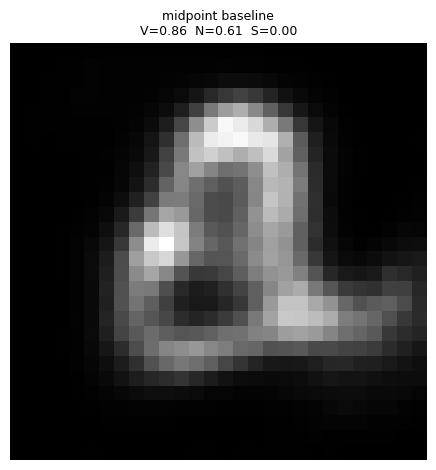

In [21]:
def get_class_mean(
    vae: nn.Module,
    train_loader: DataLoader,
    target_class: int,
    latent_dim: int = 32,
    n_batches: int = 50,
    device: torch.device = torch.device("cpu"),
) -> torch.Tensor:
    """
    Encode all images of target_class from train_loader and return
    the mean of their posterior means mu — the class centroid in
    latent space.
    """
    vae.eval()
    mus = []
    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            if i >= n_batches:
                break
            x_class = x[y == target_class].to(device)
            if len(x_class) == 0:
                continue
            _, mu, _ = vae(x_class.view(len(x_class), -1))
            mus.append(mu)
    return torch.cat(mus, dim=0).mean(dim=0)  # (latent_dim,)


# compute class centroids and midpoint
mu2      = get_class_mean(base_vae, train_loader, target_class=2,
                          latent_dim=BN_DIM, device=device)
mu6      = get_class_mean(base_vae, train_loader, target_class=6,
                          latent_dim=BN_DIM, device=device)
mu_init  = (mu2 + mu6) / 2

print(f"‖mu2‖   = {mu2.norm():.3f}")
print(f"‖mu6‖   = {mu6.norm():.3f}")
print(f"‖mu_init‖ = {mu_init.norm():.3f}")

# decode midpoint as baseline
with torch.no_grad():
    x_mid = base_vae.decode(mu_init.unsqueeze(0))
    kl_mid = 0.5 * (mu_init ** 2).sum()
    v_ = value(x_mid, value_clf)
    n_ = novelty(x_mid, digit_clf)
    s_ = surprise(kl_mid, 0.05)

plt.imshow(x_mid.view(28, 28).cpu(), cmap="gray")
plt.title(f"midpoint baseline\nV={v_:.2f}  N={n_:.2f}  S={s_:.2f}", fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

### Gaussian

#### Functions

In [86]:
import numpy as np

def creative_region_optimization(
    vae: nn.Module,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    latent_dim: int = 32,
    n_samples: int = 1028,
    n_steps: int = 100,
    mu_init: torch.Tensor | None = mu_init,
    l2_scaling: float = 1.0,
    sigma_max: float = 0.5,
    sigma_min: float = 0.01,
    lr: float = 0.001,
    lambda_s: float = 0.05,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    c1: int = 2,
    c2: int = 6,
    device: torch.device = torch.device("cpu"),
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, dict]:

    vae.eval()
    digit_classifier.eval()
    value_classifier.eval()

    eps = 1e-8
    r   = float(latent_dim) ** 0.5  # ball radius = E[||z||] for z ~ N(0, I)

    # variational parameters
    if mu_init is not None:
        mu = mu_init.clone().to(device).requires_grad_(True)
    else:
        mu = torch.zeros(latent_dim, device=device, requires_grad=True)

    log_sigma = torch.full((latent_dim,), -0.5, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([mu, log_sigma], lr=lr)

    history = {
        "dc": [], "v": [], "n": [], "s": [],
        "mu_norm": [], "sigma_mean": [],
    }

    print(f"── Creative Region Optimization ────────────────────────────")
    print(f"   n_samples={n_samples}  n_steps={n_steps}  lr={lr}  r={r:.2f}")
    print(f"   weights V={value_weight}  N={novelty_weight}  S={surprise_weight}")
    print()

    for step in range(n_steps):
        optimizer.zero_grad()

        sigma = torch.exp(log_sigma)                               # (latent_dim,)

        # reparameterize: z = mu + sigma * epsilon, epsilon ~ N(0, I)
        epsilon = torch.randn(n_samples, latent_dim, device=device)
        z       = mu.unsqueeze(0) + sigma.unsqueeze(0) * epsilon   # (n_samples, latent_dim)

        x_hat = vae.decode(z.view(n_samples, latent_dim))          # (n_samples, 784)
        kl_z  = 0.5 * (z ** 2).sum(dim=1).mean()                   # surprise proxy ½||z||²

        log_dc, log_v, log_n, log_s, v, n, s = log_creativity_score(
            x_hat, kl_z,
            digit_classifier, value_classifier,
            value_weight, novelty_weight, surprise_weight,
            lambda_s, c1, c2, eps,
        )

        loss = -log_dc
        loss.backward()
        optimizer.step()

        # projections
        with torch.no_grad():
            mu_norm = mu.norm()
            if mu_norm > r * l2_scaling:
                mu.data = mu * (r / mu_norm)

            log_sigma.clamp_(
                min=np.log(sigma_min),
                max=np.log(sigma_max)
            )


        # record history
        with torch.no_grad():
            sigma_det = torch.exp(log_sigma)
            dc_scalar = torch.exp(
                value_weight    * torch.log(v + eps)
                + novelty_weight  * torch.log(n + eps)
                + surprise_weight * torch.log(s + eps)
            )
            history["dc"].append(dc_scalar.item())
            history["v"].append(v.item())
            history["n"].append(n.item())
            history["s"].append(s.item())
            history["mu_norm"].append(mu.norm().item())
            history["sigma_mean"].append(sigma_det.mean().item())

        if (step + 1) % 10 == 0:
            window   = min(100, step + 1)
            dc_avg   = sum(history["dc"][-window:])   / window
            n_avg    = sum(history["n"][-window:])    / window
            s_avg    = sum(history["s"][-window:])    / window
            print(
                f"  step {step + 1:>4}/{n_steps}"
                f"  DC={dc_avg:.4f} (avg{window})"
                f"  V={v.item():.3f}"
                f"  N={n_avg:.3f}"
                f"  S={s_avg:.3f}"
                f"  ‖mu‖={mu.norm().item():.2f}"
                f"  sigma_mean={sigma_det.mean().item():.3f}"
            )

    with torch.no_grad():
        mu_opt    = mu.detach()
        sigma_opt = torch.exp(log_sigma).detach()

        epsilon_final = torch.randn(n_samples, latent_dim, device=device)
        z_samples     = mu_opt.unsqueeze(0) + sigma_opt.unsqueeze(0) * epsilon_final
        x_samples     = vae.decode(z_samples)

    return mu_opt, sigma_opt, x_samples, z_samples, history

##### Plotting

In [87]:
def plot_creative_region(
    mu_opt: torch.Tensor,
    sigma_opt: torch.Tensor,
    x_samples: torch.Tensor,
    z_samples: torch.Tensor,
    history: dict,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    lambda_s: float = 0.05,
    c1: int = 2,
    c2: int = 6,
    device: torch.device = torch.device("cpu"),
) -> None:
    """
    Three plots:
      1. Top 6 samples from q* ranked by DC score. Each sample is scored
         individually using component functions directly — bypasses
         log_creativity_score to avoid batch-averaging artifacts.
         kl_i = ½||z_i||² uses the actual z that produced each sample
         so S reflects the true distance from the origin, not the centre mu.
      2. Optimization trajectories: DC, N, S, mu_norm with rolling average.
      3. Per-axis sigma* — reveals the geometry of the creative region.
         Dimensions with sigma* >> 1 are broad creative axes;
         dimensions with sigma* << 1 are narrow ridges.
    """
    eps       = 1e-8
    n_samples = x_samples.size(0)

    # ── score all samples from q* ──────────────────────────────────
    dc_scores, vs, ns, ss = [], [], [], []
    with torch.no_grad():
        for i in range(n_samples):
            x_i  = x_samples[i].unsqueeze(0)          # (1, 784)
            kl_i = 0.5 * (z_samples[i] ** 2).sum()    # ½||z_i||² for this sample

            v_i = value(x_i, value_classifier, eps)
            n_i = novelty(x_i, digit_classifier, c1, c2, eps)
            s_i = surprise(kl_i, lambda_s)

            raw_dc = torch.exp(
                value_weight    * torch.log(v_i + eps)
                + novelty_weight  * torch.log(n_i + eps)
                + surprise_weight * torch.log(s_i + eps)
            )
            dc_scores.append(raw_dc.item())
            vs.append(v_i.item())
            ns.append(n_i.item())
            ss.append(s_i.item())

    dc_tensor = torch.tensor(dc_scores)
    top6_idx  = dc_tensor.topk(min(6, n_samples)).indices

    # ── plot 1: top 6 samples ──────────────────────────────────────
    fig, axes = plt.subplots(1, len(top6_idx), figsize=(12, 2.5))
    for plot_i, sample_i in enumerate(top6_idx):
        img = x_samples[sample_i].view(28, 28).cpu().detach()
        axes[plot_i].imshow(img, cmap="gray")
        axes[plot_i].axis("off")
        axes[plot_i].set_title(
            f"DC={dc_scores[sample_i]:.3f}\n"
            f"V={vs[sample_i]:.2f} "
            f"N={ns[sample_i]:.2f} "
            f"S={ss[sample_i]:.2f}",
            fontsize=7,
        )
    plt.suptitle("Top creative samples from optimized region q*", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── plot 2: optimization trajectories ─────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    labels = ["DC", "N", "S", "‖mu‖"]
    keys   = ["dc", "n", "s", "mu_norm"]
    ylims  = [(0, 1), (0, 1), (0, 1), (0, None)]
    for ax, label, key, ylim in zip(axes, labels, keys, ylims):
        raw    = history[key]
        window = min(100, len(raw))
        avg    = [
            sum(raw[max(0, i - window):i + 1]) / min(window, i + 1)
            for i in range(len(raw))
        ]
        ax.plot(raw, alpha=0.2, color="steelblue")
        ax.plot(avg, color="steelblue", linewidth=1.5)
        ax.set_ylabel(label)
        ax.set_ylim(*ylim)
    axes[-1].set_xlabel("optimization step")
    plt.suptitle("Optimization trajectories — creative region", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── plot 3: per-axis sigma* ────────────────────────────────────
    sigma_np = sigma_opt.cpu().numpy()
    fig, ax  = plt.subplots(figsize=(12, 3))
    ax.bar(range(len(sigma_np)), sigma_np, color="steelblue", alpha=0.8)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8,
               label="prior sigma=1")
    ax.axhline(float(sigma_opt.mean()), color="tomato", linestyle="--",
               linewidth=0.8,
               label=f"mean sigma*={float(sigma_opt.mean()):.3f}")
    ax.set_xlabel("latent dimension")
    ax.set_ylabel("sigma*")
    ax.set_title("Per-axis width of optimized creative region")
    ax.legend()
    plt.tight_layout()
    plt.show()


def sample_creative_region(
    vae: nn.Module,
    mu_opt: torch.Tensor,
    sigma_opt: torch.Tensor,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    n_samples: int = 50,
    lambda_s: float = 0.05,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    c1: int = 2,
    c2: int = 6,
    n_display: int = 6,
    device: torch.device = torch.device("cpu"),
) -> tuple[torch.Tensor, torch.Tensor, list[dict]]:
    """
    Sample from the optimized creative region q* = N(mu_opt, sigma_opt^2 * I),
    score each sample individually, and produce three plots:
      1. Top n_display samples ranked by DC
      2. Distribution of DC, V, N, S across all samples — shows whether
         the region is consistently creative or has a long tail of low scores
      3. DC vs N and DC vs S scatter — reveals which component drives DC variance
    """
    vae.eval()
    digit_classifier.eval()
    value_classifier.eval()

    eps = 1e-8

    with torch.no_grad():
        # sample from q*
        epsilon   = torch.randn(n_samples, mu_opt.shape[0], device=device)
        z_samples = mu_opt.unsqueeze(0) + sigma_opt.unsqueeze(0) * epsilon
        x_samples = vae.decode(z_samples)

        # score each sample individually
        scores = []
        for i in range(n_samples):
            x_i  = x_samples[i].unsqueeze(0)
            kl_i = 0.5 * (z_samples[i] ** 2).sum()

            v_i  = value(x_i, value_classifier, eps)
            n_i  = novelty(x_i, digit_classifier, c1, c2, eps)
            s_i  = surprise(kl_i, lambda_s)
            dc_i = torch.exp(
                value_weight    * torch.log(v_i + eps)
                + novelty_weight  * torch.log(n_i + eps)
                + surprise_weight * torch.log(s_i + eps)
            )
            scores.append({
                "idx": i,
                "dc": dc_i.item(),
                "v":  v_i.item(),
                "n":  n_i.item(),
                "s":  s_i.item(),
            })

        scores = sorted(scores, key=lambda d: d["dc"], reverse=True)

    dc_arr = np.array([d["dc"] for d in scores])
    v_arr  = np.array([d["v"]  for d in scores])
    n_arr  = np.array([d["n"]  for d in scores])
    s_arr  = np.array([d["s"]  for d in scores])

    # ── plot 1: top n_display samples ─────────────────────────────
    top_idx = [d["idx"] for d in scores[:n_display]]
    fig, axes = plt.subplots(1, n_display, figsize=(2 * n_display, 2.5))
    for plot_i, sample_i in enumerate(top_idx):
        img = x_samples[sample_i].view(28, 28).cpu()
        axes[plot_i].imshow(img, cmap="gray")
        axes[plot_i].axis("off")
        axes[plot_i].set_title(
            f"DC={scores[plot_i]['dc']:.3f}\n"
            f"V={scores[plot_i]['v']:.2f} "
            f"N={scores[plot_i]['n']:.2f} "
            f"S={scores[plot_i]['s']:.2f}",
            fontsize=7,
        )
    plt.suptitle(
        f"Top samples from q*  |  mu_norm={mu_opt.norm():.2f}"
        f"  sigma_mean={sigma_opt.mean():.3f}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ── plot 2: score distributions ───────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    for ax, arr, label, color in zip(
        axes,
        [dc_arr, v_arr, n_arr, s_arr],
        ["DC", "V", "N", "S"],
        ["steelblue", "#1D9E75", "#BA7517", "#D4537E"],
    ):
        ax.hist(arr, bins=30, color=color, alpha=0.8, edgecolor="none")
        ax.axvline(arr.mean(), color="black", linestyle="--",
                   linewidth=1.0, label=f"mean={arr.mean():.3f}")
        ax.axvline(np.median(arr), color="gray", linestyle=":",
                   linewidth=1.0, label=f"median={np.median(arr):.3f}")
        ax.set_xlabel(label)
        ax.set_ylabel("count")
        ax.set_xlim(0, 1)
        ax.legend(fontsize=7)
    plt.suptitle(
        f"Score distributions over {n_samples} samples from q*"
        f"  (std: DC={dc_arr.std():.3f} V={v_arr.std():.3f}"
        f" N={n_arr.std():.3f} S={s_arr.std():.3f})",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ── plot 3: component scatter ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    for ax, arr, label, color in zip(
        axes,
        [v_arr, n_arr, s_arr],
        ["V", "N", "S"],
        ["#1D9E75", "#BA7517", "#D4537E"],
    ):
        ax.scatter(arr, dc_arr, alpha=0.4, s=10, color=color)
        # correlation
        rho = np.corrcoef(arr, dc_arr)[0, 1]
        ax.set_xlabel(label)
        ax.set_ylabel("DC")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f"DC vs {label}  (r={rho:.3f})", fontsize=9)
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
                linewidth=0.8, alpha=0.5)

    plt.suptitle("DC component correlations", fontsize=9)
    plt.tight_layout()
    plt.show()

    return x_samples, z_samples, scores

#### Experiment: Regular vs Creative Latent Space

In [74]:
# ── base VAE ──────────────────────────────────────────────────────
mu_opt, sigma_opt, x_samples, z_samples, history = creative_region_optimization(
    vae=base_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    latent_dim=BN_DIM,
    n_samples=1028,
    n_steps=200,
    mu_init=mu_init,
    lr=0.005,
    l2_scaling = 1.75,
    sigma_max=0.3,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

── Creative Region Optimization ────────────────────────────
   n_samples=1028  n_steps=200  lr=0.005  r=5.66
   weights V=0.3  N=0.4  S=0.3

  step   10/200  DC=0.3552 (avg10)  V=0.901  N=0.536  S=0.091  ‖mu‖=0.41  sigma_mean=0.299
  step   20/200  DC=0.3551 (avg20)  V=0.925  N=0.546  S=0.083  ‖mu‖=0.65  sigma_mean=0.299
  step   30/200  DC=0.3605 (avg30)  V=0.937  N=0.555  S=0.083  ‖mu‖=0.94  sigma_mean=0.298
  step   40/200  DC=0.3685 (avg40)  V=0.945  N=0.563  S=0.086  ‖mu‖=1.26  sigma_mean=0.297
  step   50/200  DC=0.3786 (avg50)  V=0.954  N=0.571  S=0.092  ‖mu‖=1.59  sigma_mean=0.296
  step   60/200  DC=0.3901 (avg60)  V=0.961  N=0.580  S=0.099  ‖mu‖=1.91  sigma_mean=0.295
  step   70/200  DC=0.4024 (avg70)  V=0.959  N=0.588  S=0.108  ‖mu‖=2.23  sigma_mean=0.294
  step   80/200  DC=0.4153 (avg80)  V=0.957  N=0.596  S=0.118  ‖mu‖=2.52  sigma_mean=0.292
  step   90/200  DC=0.4285 (avg90)  V=0.959  N=0.605  S=0.129  ‖mu‖=2.81  sigma_mean=0.290
  step  100/200  DC=0.4420 (avg100)  V=

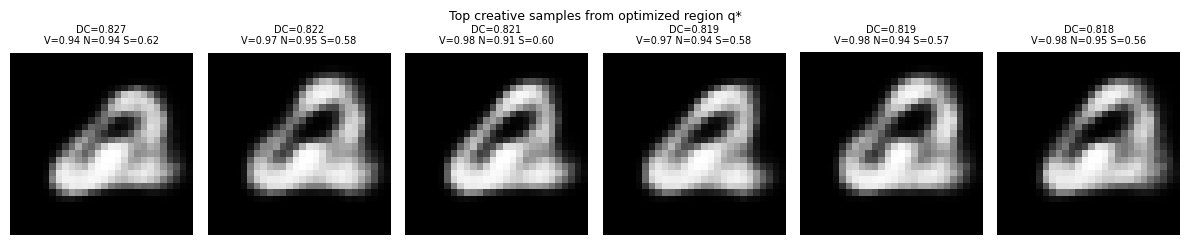

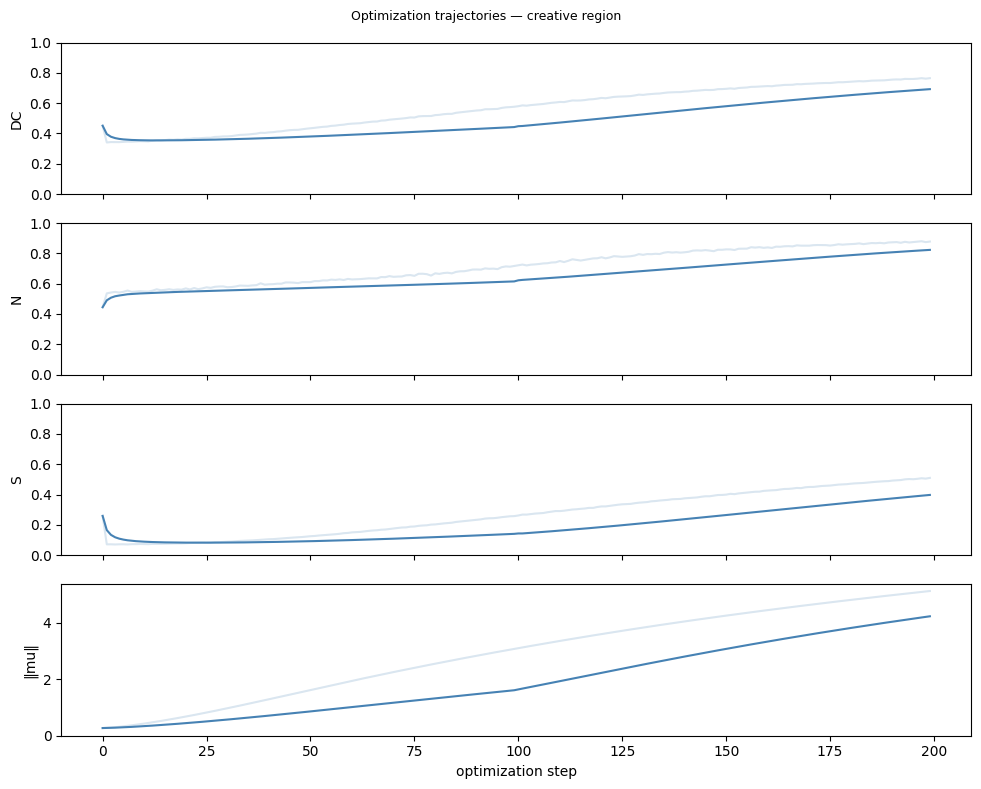

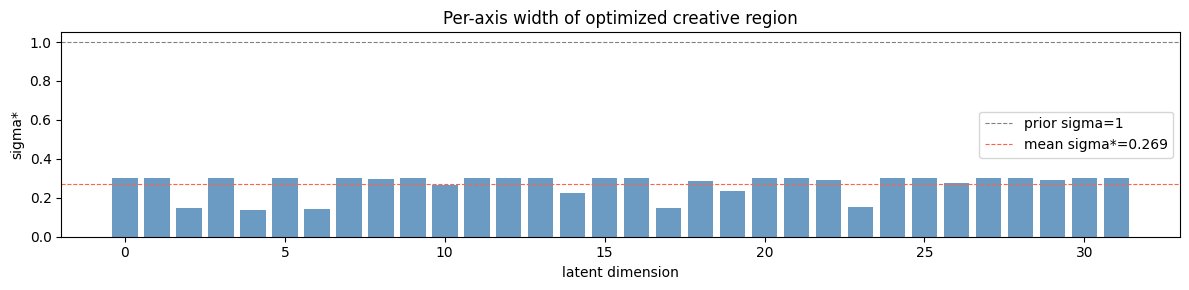

In [75]:
plot_creative_region(
    mu_opt=mu_opt,
    sigma_opt=sigma_opt,
    x_samples=x_samples,
    z_samples=z_samples,
    history=history,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    lambda_s=0.05,
    device=device,
)

In [77]:
# ── Creative VAE ──────────────────────────────────────────────────────
mu_opt_c, sigma_opt_c, x_samples_c, z_samples_c, history_c = creative_region_optimization(
    vae=creative_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    latent_dim=BN_DIM,
    n_samples=1028,
    n_steps=200,
    mu_init=mu_init,
    sigma_max=0.3,
    lr=0.005,
    l2_scaling=1.75,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

── Creative Region Optimization ────────────────────────────
   n_samples=1028  n_steps=200  lr=0.005  r=5.66
   weights V=0.3  N=0.4  S=0.3

  step   10/200  DC=0.3770 (avg10)  V=0.945  N=0.592  S=0.091  ‖mu‖=0.43  sigma_mean=0.300
  step   20/200  DC=0.3750 (avg20)  V=0.951  N=0.601  S=0.084  ‖mu‖=0.68  sigma_mean=0.299
  step   30/200  DC=0.3798 (avg30)  V=0.961  N=0.610  S=0.084  ‖mu‖=0.97  sigma_mean=0.298
  step   40/200  DC=0.3878 (avg40)  V=0.964  N=0.618  S=0.087  ‖mu‖=1.30  sigma_mean=0.297
  step   50/200  DC=0.3977 (avg50)  V=0.966  N=0.625  S=0.093  ‖mu‖=1.62  sigma_mean=0.297
  step   60/200  DC=0.4091 (avg60)  V=0.974  N=0.632  S=0.100  ‖mu‖=1.95  sigma_mean=0.296
  step   70/200  DC=0.4211 (avg70)  V=0.974  N=0.639  S=0.110  ‖mu‖=2.26  sigma_mean=0.295
  step   80/200  DC=0.4337 (avg80)  V=0.978  N=0.645  S=0.120  ‖mu‖=2.55  sigma_mean=0.294
  step   90/200  DC=0.4464 (avg90)  V=0.981  N=0.652  S=0.131  ‖mu‖=2.83  sigma_mean=0.293
  step  100/200  DC=0.4593 (avg100)  V=

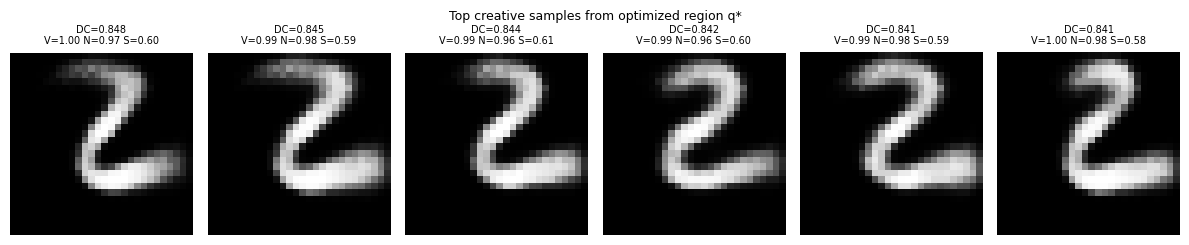

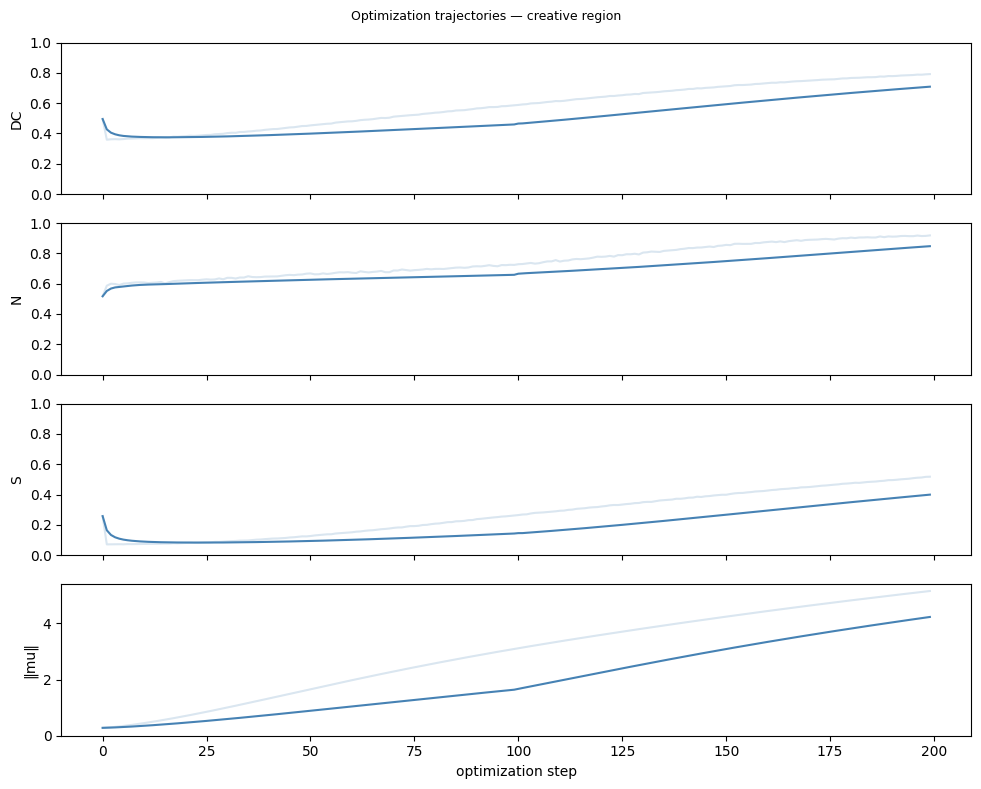

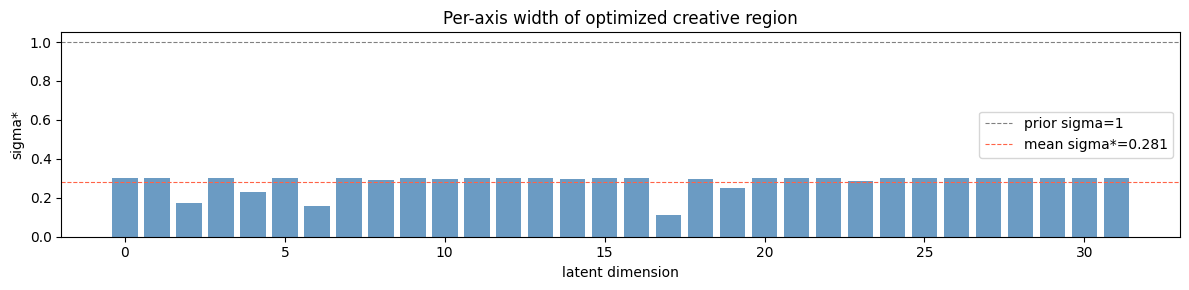

In [78]:
plot_creative_region(
    mu_opt=mu_opt_c,
    sigma_opt=sigma_opt_c,
    x_samples=x_samples_c,
    z_samples=z_samples_c,
    history=history_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    lambda_s=0.05,
    device=device,
)

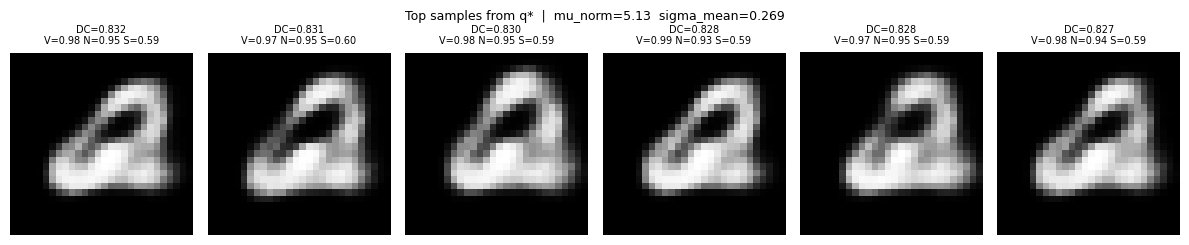

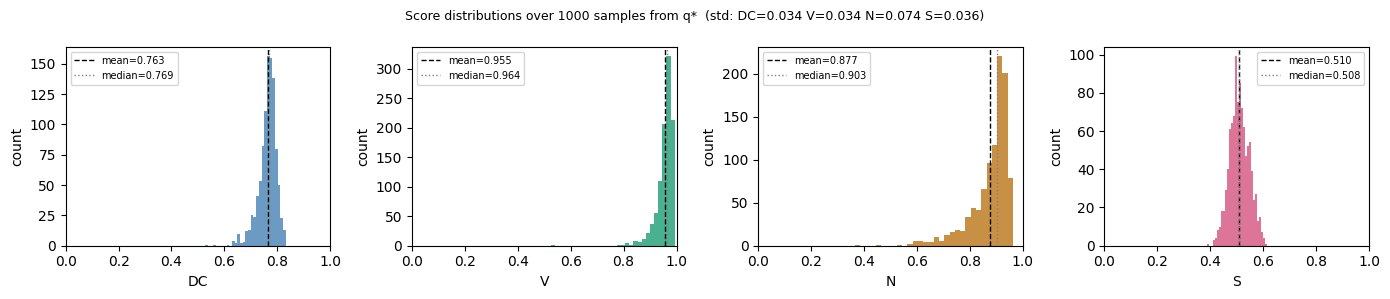

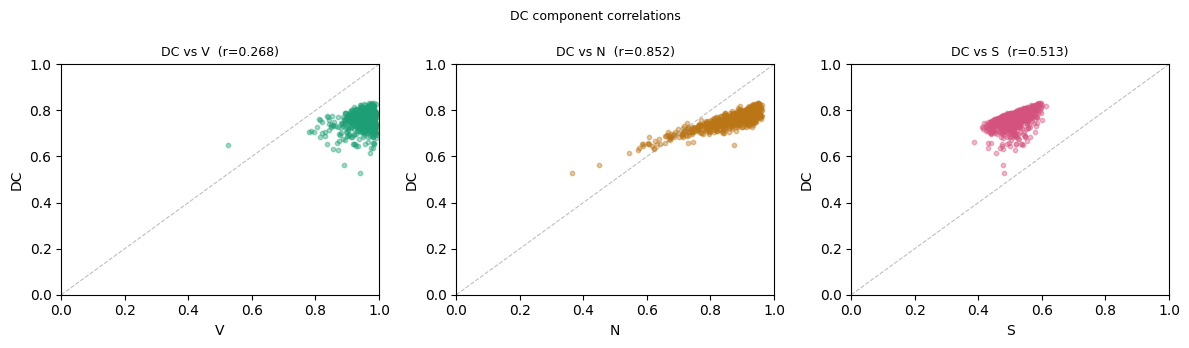

In [80]:
x_samples, z_samples, scores = sample_creative_region(
    vae=base_vae,
    mu_opt=mu_opt,
    sigma_opt=sigma_opt,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    n_samples=1000,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

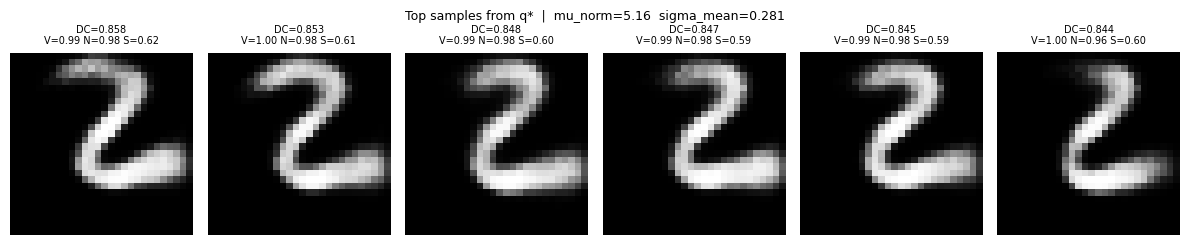

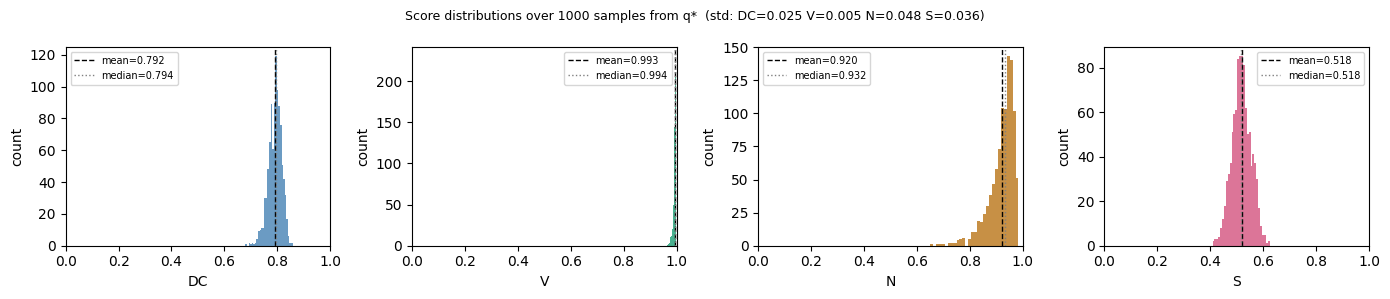

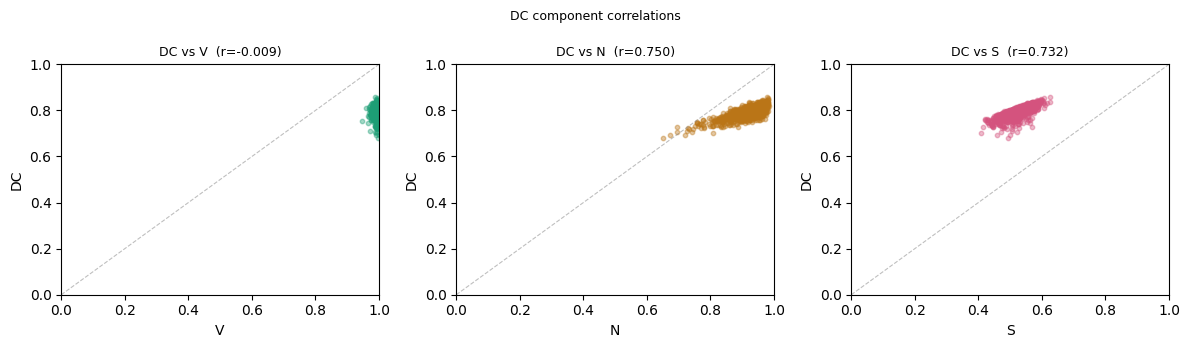

In [81]:
x_samples_c, z_samples_c, scores_c = sample_creative_region(
    vae=creative_vae,
    mu_opt=mu_opt_c,
    sigma_opt=sigma_opt_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    n_samples=1000,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

In [52]:
save_dir = "model_samples"
os.makedirs(save_dir, exist_ok=True)

torch.save(x_samples.cpu(),   os.path.join(save_dir, "base_uni_latent_optim.pt"))
torch.save(x_samples_c.cpu(), os.path.join(save_dir, "creative_uni_latent_optim.pt"))

print(f"Saved → {save_dir}/base_uni_latent_optim.pt")
print(f"Saved → {save_dir}/creative_uni_latent_optim.pt")

Saved → model_samples/base_latent_optim.pt
Saved → model_samples/creative_latent_optim.pt


### Gaussian Mixture

#### Functions

In [144]:
def creative_mixture_optimization(
    vae: nn.Module,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    latent_dim: int = 32,
    K: int = 5,
    n_samples_per_component: int = 256,
    n_steps: int = 500,
    mu_init: Optional[torch.Tensor] = None,
    l2_scaling: float = 1.0,
    sigma_max: float = 0.5,
    sigma_min: float = 0.05,
    entropy_weight: float = 0.01,
    lr: float = 0.001,
    lambda_s: float = 0.05,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    c1: int = 2,
    c2: int = 6,
    device: torch.device = torch.device("cpu"),
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, dict]:
    """
    Creative region optimization with a Gaussian mixture posterior:

        q*(z) = sum_k pi_k * N(mu_k, sigma_k^2 * I)

    Each component k finds an independent creative hotspot. DC is computed
    separately per component and combined as a pi-weighted sum:

        loss = -sum_k pi_k * log_DC_k - entropy_weight * H(pi)

    This gives log_pi a direct gradient signal — components with higher DC
    get higher weight, and the gradient of the weighted sum w.r.t. log_pi
    is proportional to the DC difference between components. The previous
    formulation used pi.detach() for sample allocation so log_pi only
    received gradient from the entropy term, keeping weights stuck at 1/K.

    mu_k are projected onto the l2 ball of radius r = sqrt(latent_dim) * l2_scaling
    after each step. sigma is clamped to [sigma_min, sigma_max].

    Returns:
        mu_opt      — (K, latent_dim) component centres
        sigma_opt   — (K, latent_dim) per-axis widths
        pi_opt      — (K,) mixture weights
        x_samples   — (K * n_samples_per_component, 784) decoded images
        z_samples   — (K * n_samples_per_component, latent_dim) latent vectors
        history     — per-step traces of DC, V, N, S, pi, mu_norms
    """
    vae.eval()
    digit_classifier.eval()
    value_classifier.eval()

    eps = 1e-8
    r   = float(latent_dim) ** 0.5 * l2_scaling
    mu_init = mu_init.cpu()

    # ── initialise parameters ──────────────────────────────────────
    if mu_init is not None:
        mu_data = mu_init.unsqueeze(0).expand(K, -1).clone()
        mu_data[1:] = mu_data[1:] + 2 * torch.randn(K - 1, latent_dim)
    else:
        mu_data = torch.randn(K, latent_dim) * (r / latent_dim ** 0.5)

    mu        = mu_data.to(device).requires_grad_(True)
    log_sigma = torch.full((K, latent_dim), np.log(sigma_min),
                           device=device, requires_grad=True)
    log_pi    = torch.zeros(K, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([mu, log_sigma, log_pi], lr=lr)

    history = {
        "dc": [], "v": [], "n": [], "s": [],
        "pi": [], "mu_norms": [],
    }

    n_total = K * n_samples_per_component

    print(f"── Creative Mixture Optimization ───────────────────────────")
    print(f"   K={K}  n_samples_per_component={n_samples_per_component}"
          f"  n_steps={n_steps}  lr={lr}  r={r:.2f}")
    print(f"   sigma in [{sigma_min}, {sigma_max}]  entropy_weight={entropy_weight}")
    print(f"   weights V={value_weight}  N={novelty_weight}  S={surprise_weight}")
    print()

    for step in range(n_steps):
        optimizer.zero_grad()

        pi    = torch.softmax(log_pi, dim=0)    # (K,)
        sigma = torch.exp(log_sigma)             # (K, latent_dim)

        # compute DC separately per component — gradient flows into log_pi
        component_log_dcs = []
        v_sum = n_sum = s_sum = 0.0
        for k in range(K):
            eps_k   = torch.randn(n_samples_per_component, latent_dim, device=device)
            z_k     = mu[k].unsqueeze(0) + sigma[k].unsqueeze(0) * eps_k
            x_k     = vae.decode(z_k)
            kl_k    = 0.5 * (z_k ** 2).sum(dim=1).mean()

            log_dc_k, _, _, _, v_k, n_k, s_k = log_creativity_score(
                x_k, kl_k,
                digit_classifier, value_classifier,
                value_weight, novelty_weight, surprise_weight,
                lambda_s, c1, c2, eps,
            )
            component_log_dcs.append(log_dc_k)
            v_sum += v_k.item()
            n_sum += n_k.item()
            s_sum += s_k.item()

        component_log_dcs = torch.stack(component_log_dcs)   # (K,)

        # pi-weighted expected log DC — pi_k multiplies DC_k directly
        # so components with higher DC receive higher gradient into log_pi
        weighted_log_dc = (pi * component_log_dcs).sum()
        h_pi            = -(pi * torch.log(pi + eps)).sum()
        loss            = -weighted_log_dc - entropy_weight * h_pi
        loss.backward()
        optimizer.step()

        # project each mu_k onto the l2 ball
        with torch.no_grad():
            for k in range(K):
                norm_k = mu[k].norm()
                if norm_k > r:
                    mu.data[k] = mu[k] * (r / norm_k)

            log_sigma.clamp_(
                min=np.log(sigma_min),
                max=np.log(sigma_max),
            )

        # record history
        with torch.no_grad():
            mean_dc = torch.exp(weighted_log_dc).item()
            history["dc"].append(mean_dc)
            history["v"].append(v_sum / K)
            history["n"].append(n_sum / K)
            history["s"].append(s_sum / K)
            history["pi"].append(pi.detach().cpu().numpy().tolist())
            history["mu_norms"].append([mu[k].norm().item() for k in range(K)])

        if (step + 1) % 50 == 0:
            window = min(50, step + 1)
            dc_avg = sum(history["dc"][-window:]) / window
            pi_str = "  ".join(f"π{k}={pi[k].item():.2f}" for k in range(K))
            print(
                f"  step {step + 1:>4}/{n_steps}"
                f"  DC={dc_avg:.4f} (avg{window})"
                f"  V={v_sum/K:.3f}"
                f"  N={n_sum/K:.3f}"
                f"  S={s_sum/K:.3f}"
                f"  {pi_str}"
            )

    with torch.no_grad():
        mu_opt    = mu.detach()
        sigma_opt = torch.exp(log_sigma).detach()
        pi_opt    = torch.softmax(log_pi, dim=0).detach()

        # sample from final mixture q*
        z_parts = []
        for k in range(K):
            eps_k = torch.randn(n_samples_per_component, latent_dim, device=device)
            z_k   = mu_opt[k].unsqueeze(0) + sigma_opt[k].unsqueeze(0) * eps_k
            z_parts.append(z_k)
        z_samples = torch.cat(z_parts, dim=0)
        x_samples = vae.decode(z_samples)

    return mu_opt, sigma_opt, pi_opt, x_samples, z_samples, history

##### Plotting

In [98]:
def plot_creative_mixture(
    mu_opt: torch.Tensor,
    sigma_opt: torch.Tensor,
    pi_opt: torch.Tensor,
    x_samples: torch.Tensor,
    z_samples: torch.Tensor,
    history: dict,
    vae: nn.Module,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    lambda_s: float = 0.05,
    c1: int = 2,
    c2: int = 6,
    device: torch.device = torch.device("cpu"),
) -> None:
    """
    Four plots:
      1. Decoded component centres mu_k* — the K creative archetypes,
         scored individually at mu_k so S reflects the centre's surprise.
      2. Best sample per component — highest DC draw from each hotspot.
      3. Mixture weight evolution pi_k over training steps.
      4. DC trajectory with rolling average.
    """
    eps = 1e-8
    K   = mu_opt.shape[0]

    # ── plot 1: component centres ──────────────────────────────────
    with torch.no_grad():
        x_centres = vae.decode(mu_opt)   # (K, 784)

    fig, axes = plt.subplots(1, K, figsize=(2.5 * K, 2.5))
    for k in range(K):
        img  = x_centres[k].view(28, 28).cpu()
        kl_k = 0.5 * (mu_opt[k] ** 2).sum()
        v_k  = value(x_centres[k].unsqueeze(0), value_classifier, eps)
        n_k  = novelty(x_centres[k].unsqueeze(0), digit_classifier, c1, c2, eps)
        s_k  = surprise(kl_k, lambda_s)
        dc_k = torch.exp(
            value_weight    * torch.log(v_k + eps)
            + novelty_weight  * torch.log(n_k + eps)
            + surprise_weight * torch.log(s_k + eps)
        )
        axes[k].imshow(img, cmap="gray")
        axes[k].axis("off")
        axes[k].set_title(
            f"k={k}  π={pi_opt[k]:.2f}\n"
            f"DC={dc_k:.3f}  N={n_k:.2f}",
            fontsize=7,
        )
    plt.suptitle("Component centres mu_k* — creative archetypes", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── plot 2: best sample per component ─────────────────────────
    n_total    = x_samples.size(0)
    counts     = (pi_opt * n_total).round().long().clamp(min=1)
    counts[-1] = n_total - counts[:-1].sum()
    counts[-1] = counts[-1].clamp(min=1)

    fig, axes = plt.subplots(1, K, figsize=(2.5 * K, 2.5))
    offset = 0
    for k in range(K):
        n_k_samples = counts[k].item()
        best_dc     = -1
        best_img    = None
        best_scores = {}
        with torch.no_grad():
            for i in range(offset, offset + n_k_samples):
                x_i  = x_samples[i].unsqueeze(0)
                kl_i = 0.5 * (z_samples[i] ** 2).sum()
                v_i  = value(x_i, value_classifier, eps)
                n_i  = novelty(x_i, digit_classifier, c1, c2, eps)
                s_i  = surprise(kl_i, lambda_s)
                dc_i = torch.exp(
                    value_weight    * torch.log(v_i + eps)
                    + novelty_weight  * torch.log(n_i + eps)
                    + surprise_weight * torch.log(s_i + eps)
                ).item()
                if dc_i > best_dc:
                    best_dc     = dc_i
                    best_img    = x_samples[i].view(28, 28).cpu()
                    best_scores = {
                        "v": v_i.item(), "n": n_i.item(),
                        "s": s_i.item(), "dc": dc_i,
                    }
        axes[k].imshow(best_img, cmap="gray")
        axes[k].axis("off")
        axes[k].set_title(
            f"k={k}  DC={best_scores['dc']:.3f}\n"
            f"V={best_scores['v']:.2f} N={best_scores['n']:.2f}",
            fontsize=7,
        )
        offset += n_k_samples
    plt.suptitle("Best sample per component", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── plot 3: mixture weight evolution ──────────────────────────
    pi_history = np.array(history["pi"])   # (n_steps, K)
    fig, ax    = plt.subplots(figsize=(10, 3))
    for k in range(K):
        ax.plot(pi_history[:, k], label=f"π{k}", linewidth=1.5)
    ax.set_xlabel("optimization step")
    ax.set_ylabel("mixture weight")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.set_title("Mixture weight evolution — components competing for DC")
    plt.tight_layout()
    plt.show()

    # ── plot 4: DC trajectory ──────────────────────────────────────
    raw    = history["dc"]
    window = min(50, len(raw))
    avg    = [
        sum(raw[max(0, i - window):i + 1]) / min(window, i + 1)
        for i in range(len(raw))
    ]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(raw, alpha=0.2, color="steelblue")
    ax.plot(avg, color="steelblue", linewidth=1.5)
    ax.set_xlabel("optimization step")
    ax.set_ylabel("DC")
    ax.set_ylim(0, 1)
    ax.set_title("DC trajectory — mixture optimization")
    plt.tight_layout()
    plt.show()

In [99]:
def sample_creative_region(
    vae: nn.Module,
    mu_opt: torch.Tensor,
    sigma_opt: torch.Tensor,
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    n_samples: int = 50,
    lambda_s: float = 0.05,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    c1: int = 2,
    c2: int = 6,
    n_display: int = 6,
    device: torch.device = torch.device("cpu"),
) -> tuple[torch.Tensor, torch.Tensor, list[dict]]:
    """
    Sample from the optimized creative region q* = N(mu_opt, sigma_opt^2 * I),
    score each sample individually, and produce three plots:
      1. Top n_display samples ranked by DC
      2. Distribution of DC, V, N, S across all samples — shows whether
         the region is consistently creative or has a long tail of low scores
      3. DC vs V, N, S scatter — reveals which component drives DC variance

    Accepts both single-Gaussian (mu_opt shape: latent_dim) and mixture
    (mu_opt shape: K x latent_dim) outputs. For mixtures, samples are drawn
    uniformly across components.
    """
    vae.eval()
    digit_classifier.eval()
    value_classifier.eval()

    eps = 1e-8

    # handle both single Gaussian (1D mu) and mixture (2D mu)
    if mu_opt.dim() == 1:
        mu_opt    = mu_opt.unsqueeze(0)     # (1, latent_dim)
        sigma_opt = sigma_opt.unsqueeze(0)  # (1, latent_dim)

    K          = mu_opt.shape[0]
    latent_dim = mu_opt.shape[1]

    with torch.no_grad():
        # draw samples uniformly across components
        counts = torch.full((K,), n_samples // K, dtype=torch.long)
        counts[-1] += n_samples - counts.sum()  # remainder to last component

        z_parts = []
        for k in range(K):
            eps_k = torch.randn(counts[k], latent_dim, device=device)
            z_k   = mu_opt[k].unsqueeze(0) + sigma_opt[k].unsqueeze(0) * eps_k
            z_parts.append(z_k)
        z_samples = torch.cat(z_parts, dim=0)   # (n_samples, latent_dim)
        x_samples = vae.decode(z_samples)        # (n_samples, 784)

        # score each sample individually
        scores = []
        for i in range(n_samples):
            x_i  = x_samples[i].unsqueeze(0)
            kl_i = 0.5 * (z_samples[i] ** 2).sum()

            v_i  = value(x_i, value_classifier, eps)
            n_i  = novelty(x_i, digit_classifier, c1, c2, eps)
            s_i  = surprise(kl_i, lambda_s)
            dc_i = torch.exp(
                value_weight    * torch.log(v_i + eps)
                + novelty_weight  * torch.log(n_i + eps)
                + surprise_weight * torch.log(s_i + eps)
            )
            scores.append({
                "idx": i,
                "dc": dc_i.item(),
                "v":  v_i.item(),
                "n":  n_i.item(),
                "s":  s_i.item(),
            })

        scores = sorted(scores, key=lambda d: d["dc"], reverse=True)

    dc_arr = np.array([d["dc"] for d in scores])
    v_arr  = np.array([d["v"]  for d in scores])
    n_arr  = np.array([d["n"]  for d in scores])
    s_arr  = np.array([d["s"]  for d in scores])

    mu_display = mu_opt.mean(dim=0)  # mean centre for display — single or mixture

    # ── plot 1: top n_display samples ─────────────────────────────
    top_idx = [d["idx"] for d in scores[:n_display]]
    fig, axes = plt.subplots(1, n_display, figsize=(2 * n_display, 2.5))
    for plot_i, sample_i in enumerate(top_idx):
        img = x_samples[sample_i].view(28, 28).cpu()
        axes[plot_i].imshow(img, cmap="gray")
        axes[plot_i].axis("off")
        axes[plot_i].set_title(
            f"DC={scores[plot_i]['dc']:.3f}\n"
            f"V={scores[plot_i]['v']:.2f} "
            f"N={scores[plot_i]['n']:.2f} "
            f"S={scores[plot_i]['s']:.2f}",
            fontsize=7,
        )
    plt.suptitle(
        f"Top samples from q*  |  K={K}"
        f"  mu_norm={mu_display.norm():.2f}"
        f"  sigma_mean={sigma_opt.mean():.3f}"
        f"  top DC={dc_arr[:n_display].mean():.3f}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ── plot 2: score distributions ───────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    for ax, arr, label, color in zip(
        axes,
        [dc_arr, v_arr, n_arr, s_arr],
        ["DC", "V", "N", "S"],
        ["steelblue", "#1D9E75", "#BA7517", "#D4537E"],
    ):
        ax.hist(arr, bins=30, color=color, alpha=0.8, edgecolor="none")
        ax.axvline(arr.mean(), color="black", linestyle="--",
                   linewidth=1.0, label=f"mean={arr.mean():.3f}")
        ax.axvline(np.median(arr), color="gray", linestyle=":",
                   linewidth=1.0, label=f"median={np.median(arr):.3f}")
        ax.set_xlabel(label)
        ax.set_ylabel("count")
        ax.set_xlim(0, 1)
        ax.legend(fontsize=7)
    plt.suptitle(
        f"Score distributions — {n_samples} samples from q*  "
        f"(std: DC={dc_arr.std():.3f} V={v_arr.std():.3f}"
        f" N={n_arr.std():.3f} S={s_arr.std():.3f})",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ── plot 3: component scatter ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, arr, label, color in zip(
        axes,
        [v_arr, n_arr, s_arr],
        ["V", "N", "S"],
        ["#1D9E75", "#BA7517", "#D4537E"],
    ):
        ax.scatter(arr, dc_arr, alpha=0.3, s=8, color=color)
        rho = np.corrcoef(arr, dc_arr)[0, 1]
        ax.set_xlabel(label)
        ax.set_ylabel("DC")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f"DC vs {label}  (r={rho:.3f})", fontsize=9)
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
                linewidth=0.8, alpha=0.5)
    plt.suptitle("DC component correlations", fontsize=9)
    plt.tight_layout()
    plt.show()

    return x_samples, z_samples, scores

#### Experiments

In [145]:
mu_opt_mix, sigma_opt_mix, pi_opt_mix, x_samples_mix, z_samples_mix, history_mix = creative_mixture_optimization(
    vae=base_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    latent_dim=BN_DIM,
    K=5,
    n_steps=100,
    mu_init=mu_init,
    l2_scaling=1.25,
    sigma_min=0.1,
    sigma_max=0.7,
    entropy_weight=0.01,
    lr=0.005,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

── Creative Mixture Optimization ───────────────────────────
   K=5  n_samples_per_component=256  n_steps=100  lr=0.005  r=7.07
   sigma in [0.1, 0.7]  entropy_weight=0.01
   weights V=0.3  N=0.4  S=0.3

  step   50/100  DC=0.4600 (avg50)  V=0.841  N=0.550  S=0.586  π0=0.16  π1=0.26  π2=0.17  π3=0.16  π4=0.26
  step  100/100  DC=0.6492 (avg50)  V=0.912  N=0.615  S=0.602  π0=0.13  π1=0.30  π2=0.15  π3=0.13  π4=0.30


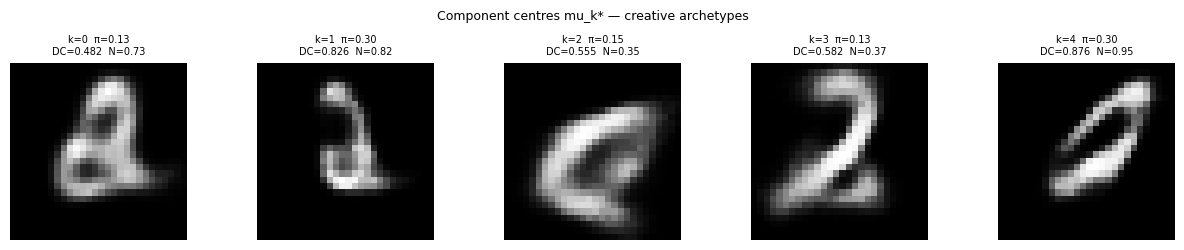

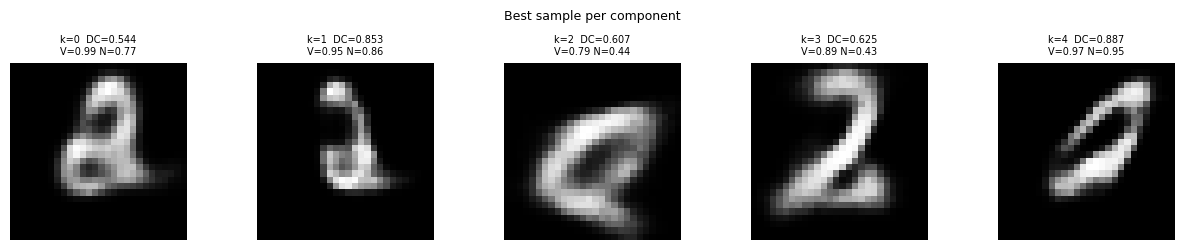

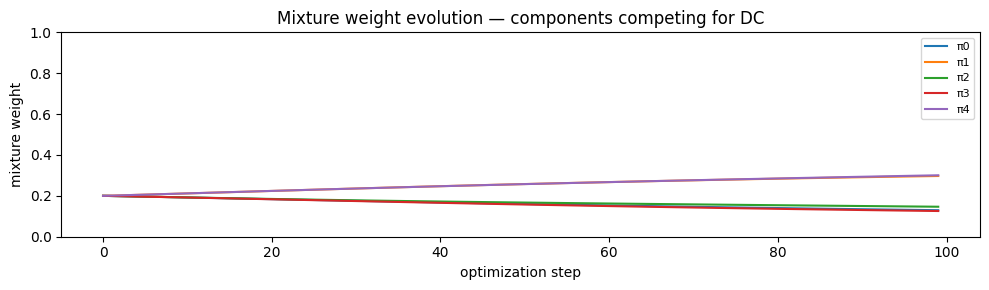

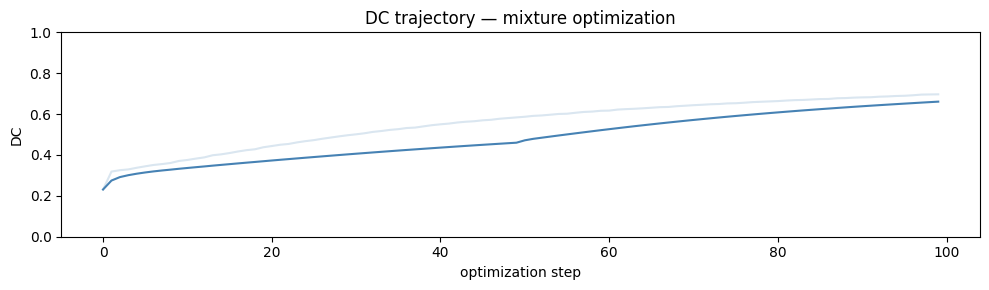

In [146]:
plot_creative_mixture(
    mu_opt=mu_opt_mix,
    sigma_opt=sigma_opt_mix,
    pi_opt=pi_opt_mix,
    x_samples=x_samples_mix,
    z_samples=z_samples_mix,
    history=history_mix,
    vae=base_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    lambda_s=0.05,
    device=device,
)

In [147]:
mu_opt_mix_c, sigma_opt_mix_c, pi_opt_mix_c, x_samples_mix_c, z_samples_mix_c, history_mix_c = creative_mixture_optimization(
    vae=creative_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    latent_dim=BN_DIM,
    K=5,
    n_steps=100,
    mu_init=mu_init,
    l2_scaling=1.25,
    sigma_min=0.1,
    sigma_max=0.5,
    entropy_weight=0.01,
    lr=0.005,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

── Creative Mixture Optimization ───────────────────────────
   K=5  n_samples_per_component=256  n_steps=100  lr=0.005  r=7.07
   sigma in [0.1, 0.5]  entropy_weight=0.01
   weights V=0.3  N=0.4  S=0.3

  step   50/100  DC=0.5184 (avg50)  V=0.983  N=0.616  S=0.586  π0=0.15  π1=0.23  π2=0.24  π3=0.15  π4=0.23
  step  100/100  DC=0.7229 (avg50)  V=0.989  N=0.745  S=0.603  π0=0.11  π1=0.25  π2=0.25  π3=0.13  π4=0.25


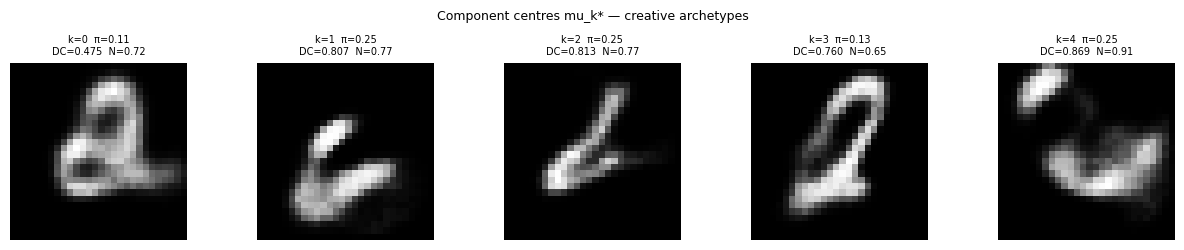

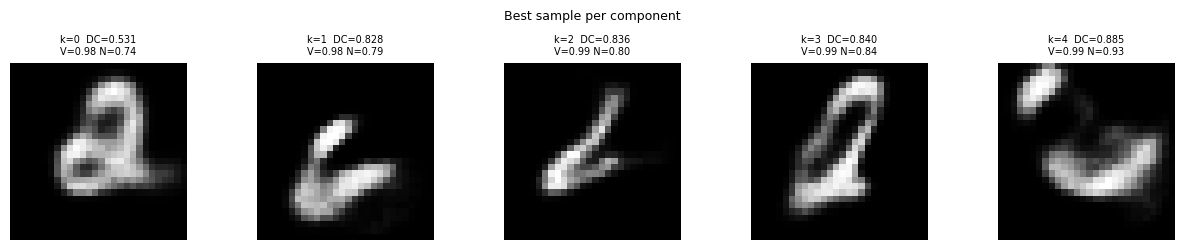

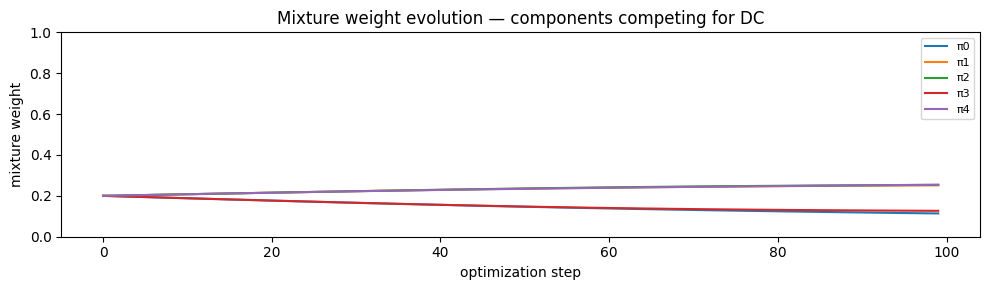

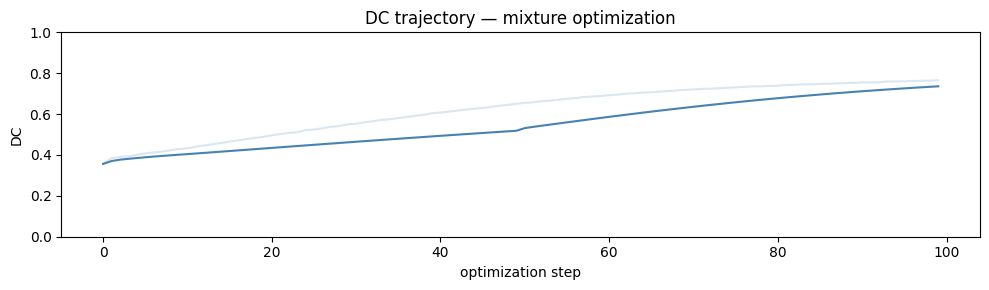

In [148]:
plot_creative_mixture(
    mu_opt=mu_opt_mix_c,
    sigma_opt=sigma_opt_mix_c,
    pi_opt=pi_opt_mix_c,
    x_samples=x_samples_mix_c,
    z_samples=z_samples_mix_c,
    history=history_mix_c,
    vae=creative_vae,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    lambda_s=0.05,
    device=device,
)

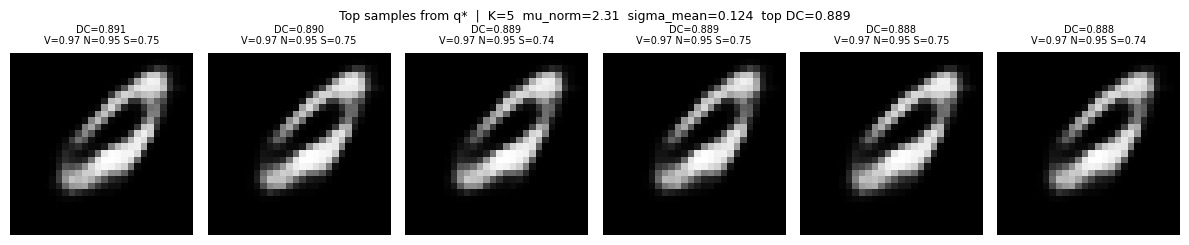

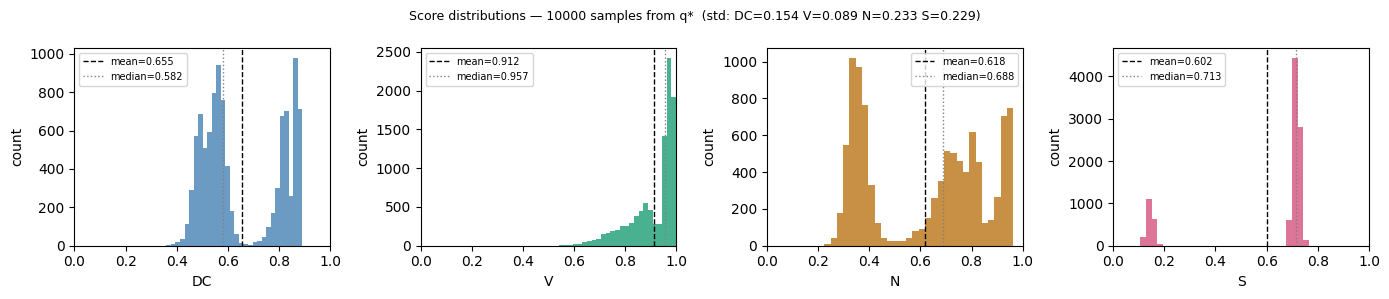

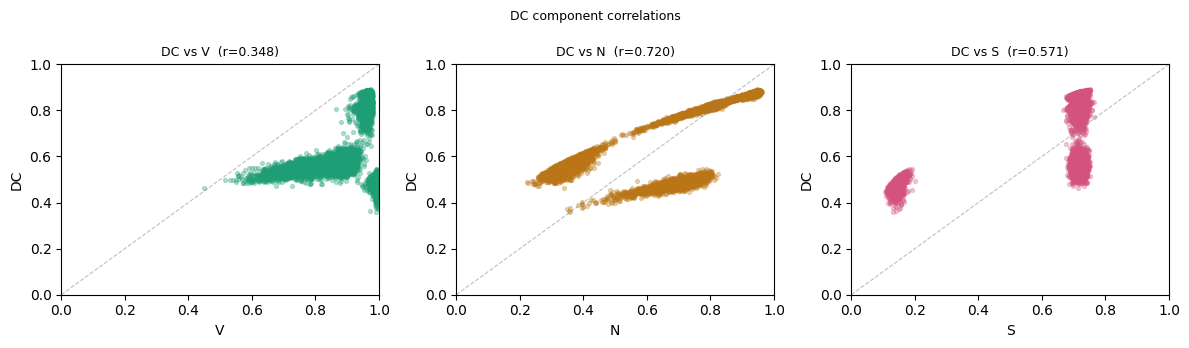

In [149]:
x_samples_mix, z_samples_mix, scores_mix = sample_creative_region(
    vae=base_vae,
    mu_opt=mu_opt_mix,
    sigma_opt=sigma_opt_mix,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    n_samples=10_000,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

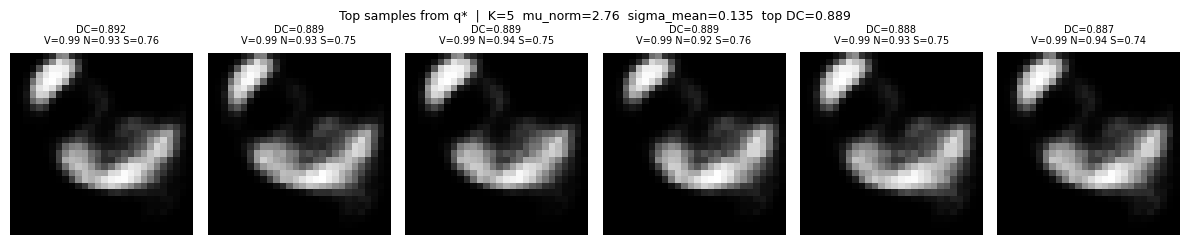

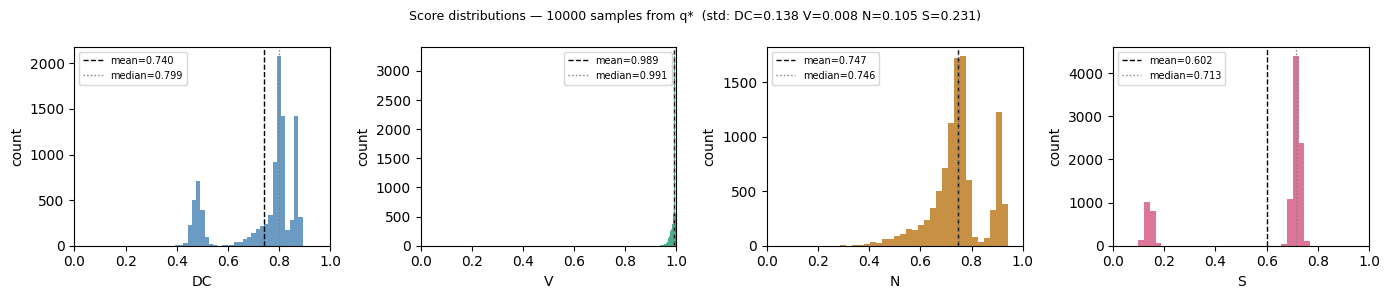

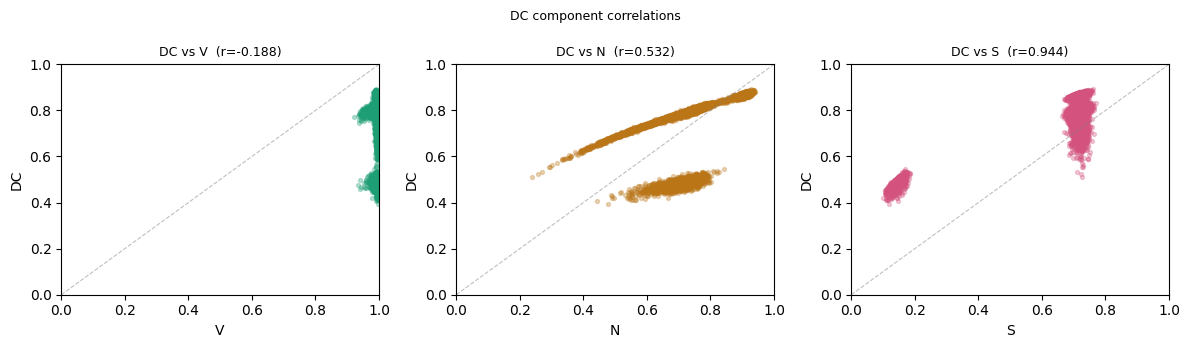

In [150]:
x_samples_mix_c, z_samples_mix_c, scores_mix_c = sample_creative_region(
    vae=creative_vae,
    mu_opt=mu_opt_mix_c,
    sigma_opt=sigma_opt_mix_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    n_samples=10_000,
    lambda_s=0.05,
    value_weight=0.30,
    novelty_weight=0.40,
    surprise_weight=0.30,
    device=device,
)

In [154]:
def plot_sample_grid(
    x_samples: torch.Tensor,
    z_samples: torch.Tensor,
    scores: list[dict],
    digit_classifier: nn.Module,
    value_classifier: nn.Module,
    value_weight: float = 0.30,
    novelty_weight: float = 0.40,
    surprise_weight: float = 0.30,
    lambda_s: float = 0.05,
    c1: int = 2,
    c2: int = 6,
    grid_size: int = 10,
    sample_from: str = "top",  # "top", "random", or "uniform"
    device: torch.device = torch.device("cpu"),
) -> None:
    """
    Plot a grid_size x grid_size grid of samples with DC, V, N, S scores.

    sample_from:
      "top"     — highest DC samples
      "random"  — random draw from all samples
      "uniform" — evenly spaced across the DC distribution
    """
    n_display = grid_size * grid_size
    eps       = 1e-8

    if sample_from == "top":
        selected = scores[:n_display]
    elif sample_from == "random":
        idx      = np.random.choice(len(scores), size=n_display, replace=False)
        selected = [scores[i] for i in idx]
    elif sample_from == "uniform":
        # evenly spaced indices across the sorted score list
        indices  = np.linspace(0, len(scores) - 1, n_display, dtype=int)
        selected = [scores[i] for i in indices]
    else:
        raise ValueError(f"sample_from must be 'top', 'random', or 'uniform'")

    fig, axes = plt.subplots(
        grid_size, grid_size,
        figsize=(grid_size * 1.8, grid_size * 2.2),
    )

    for plot_i, d in enumerate(selected):
        row = plot_i // grid_size
        col = plot_i %  grid_size
        ax  = axes[row][col]

        img = x_samples[d["idx"]].view(28, 28).cpu().detach()
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"DC={d['dc']:.2f}\n"
            f"V={d['v']:.2f} N={d['n']:.2f}\n"
            f"S={d['s']:.2f}",
            fontsize=5,
            pad=2,
        )

    dc_arr = np.array([d["dc"] for d in scores])
    plt.suptitle(
        f"{grid_size}×{grid_size} samples ({sample_from})  |  "
        f"mean DC={dc_arr.mean():.3f}  "
        f"median DC={np.median(dc_arr):.3f}  "
        f"top-100 DC={np.sort(dc_arr)[::-1][:100].mean():.3f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

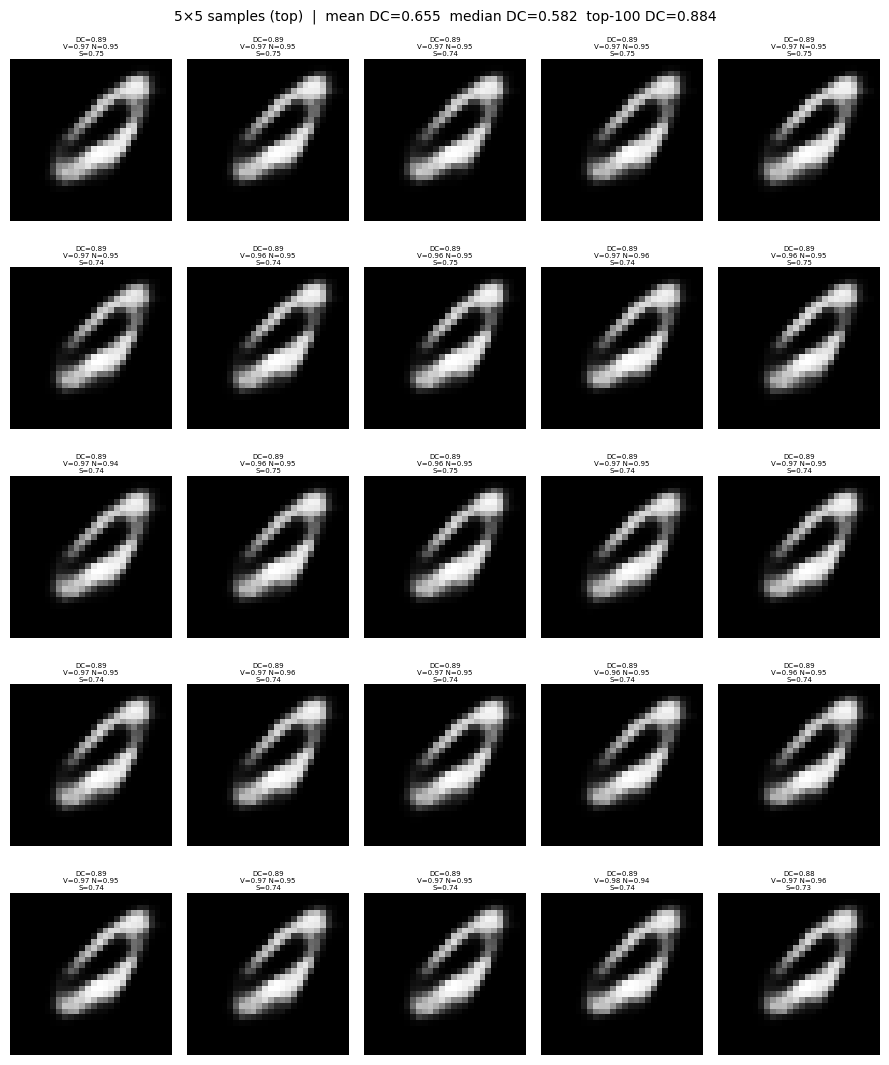

In [155]:
plot_sample_grid(
    x_samples=x_samples_mix,
    z_samples=z_samples_mix,
    scores=scores_mix,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="top",
    device=device,
    grid_size=5
)

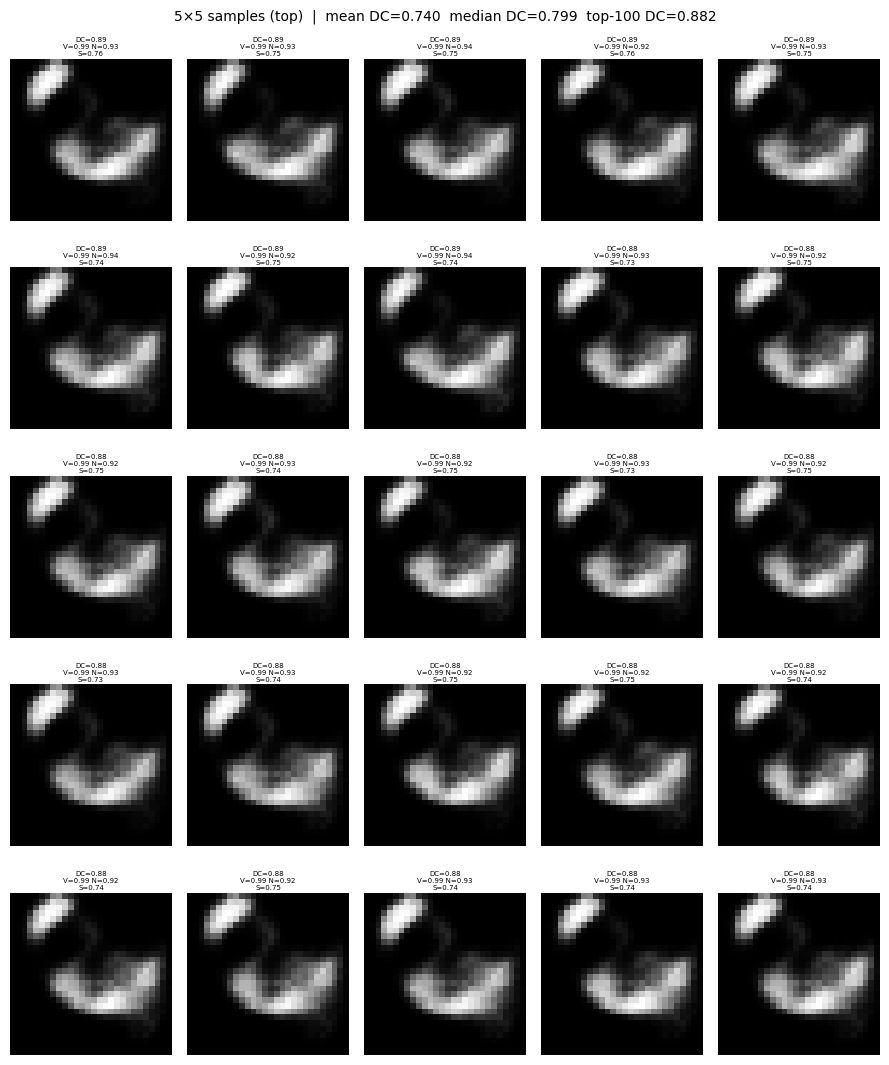

In [156]:
plot_sample_grid(
    x_samples=x_samples_mix_c,
    z_samples=z_samples_mix_c,
    scores=scores_mix_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="top",
    device=device,
    grid_size=5
)

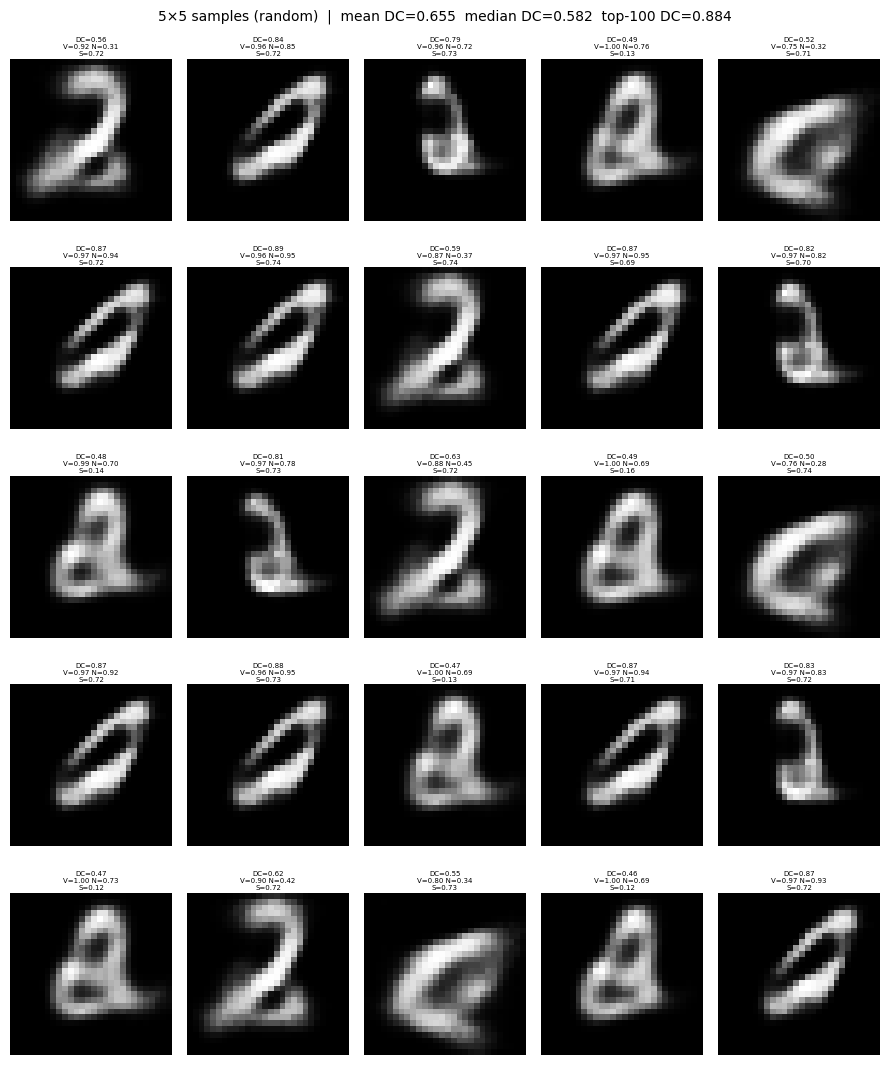

In [157]:
plot_sample_grid(
    x_samples=x_samples_mix,
    z_samples=z_samples_mix,
    scores=scores_mix,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="random",
    device=device,
    grid_size=5
)

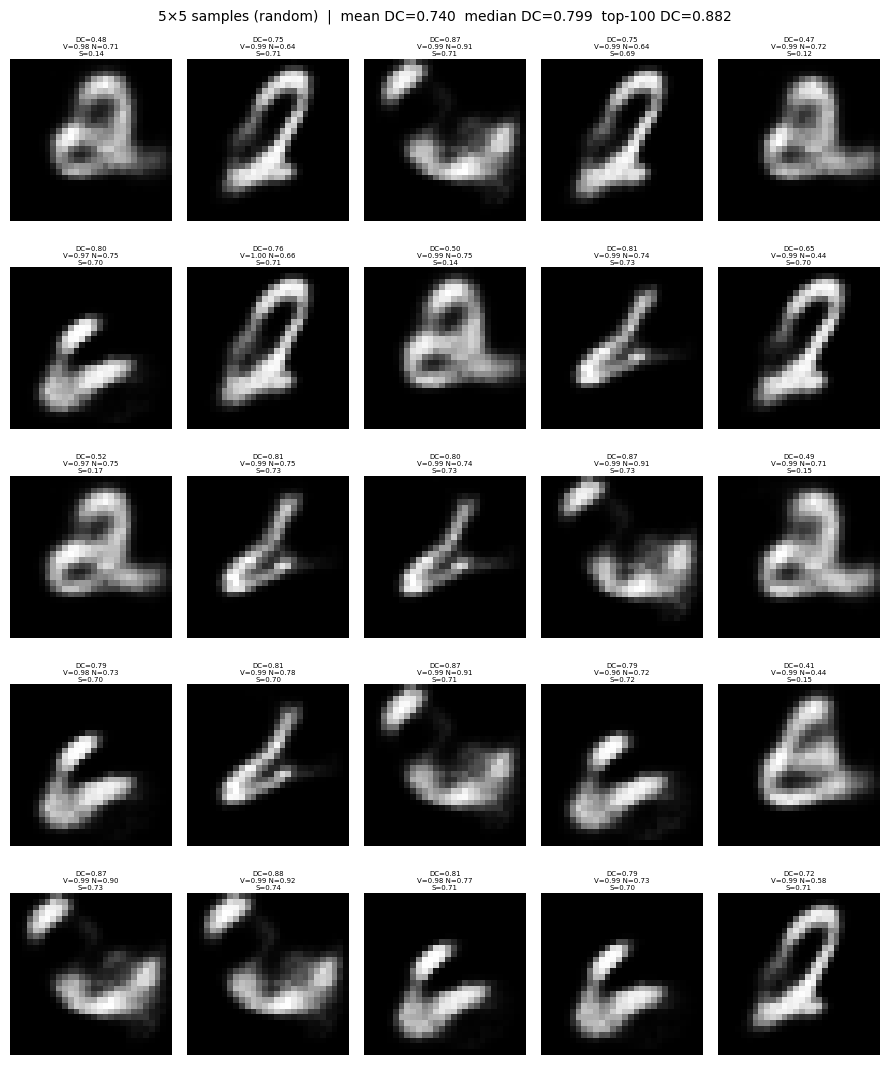

In [158]:
# ── random sample ──────────────────────────────────────────────
plot_sample_grid(
    x_samples=x_samples_mix_c,
    z_samples=z_samples_mix_c,
    scores=scores_mix_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="random",
    device=device,
    grid_size=5
)

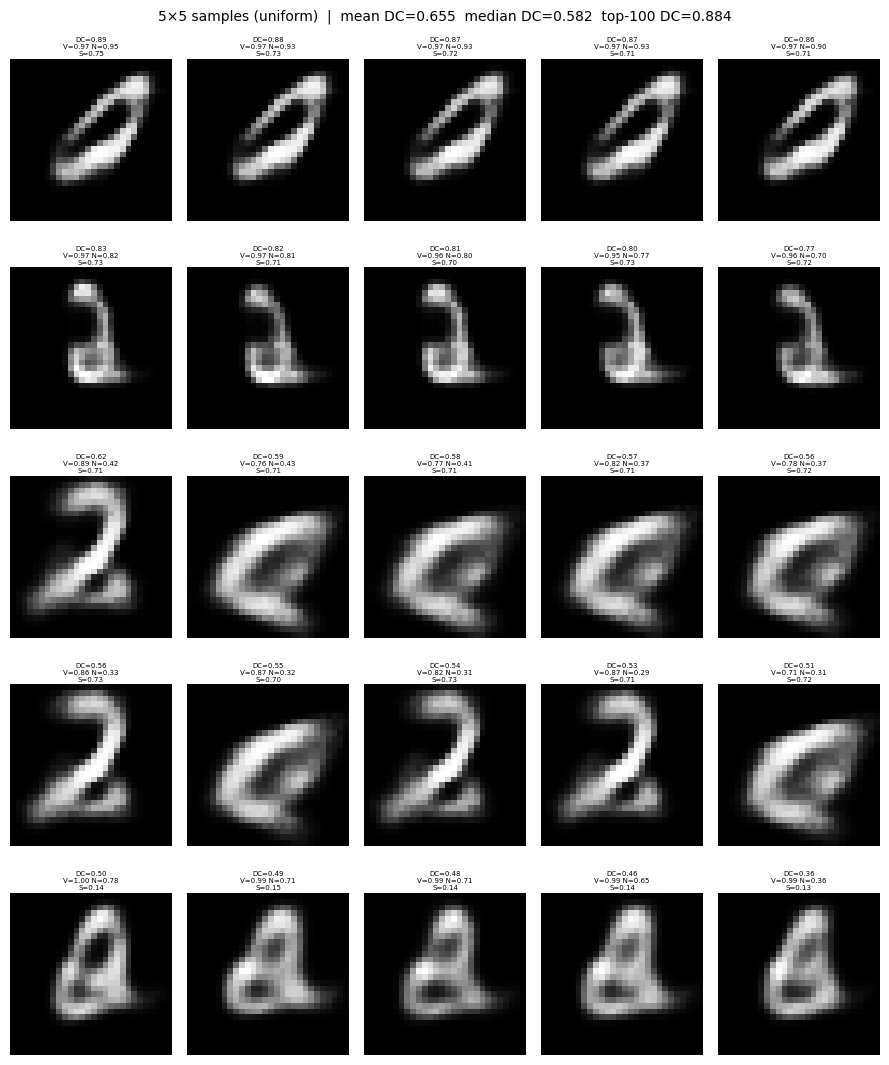

In [159]:
plot_sample_grid(
    x_samples=x_samples_mix,
    z_samples=z_samples_mix,
    scores=scores_mix,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="uniform",
    device=device,
    grid_size=5
)

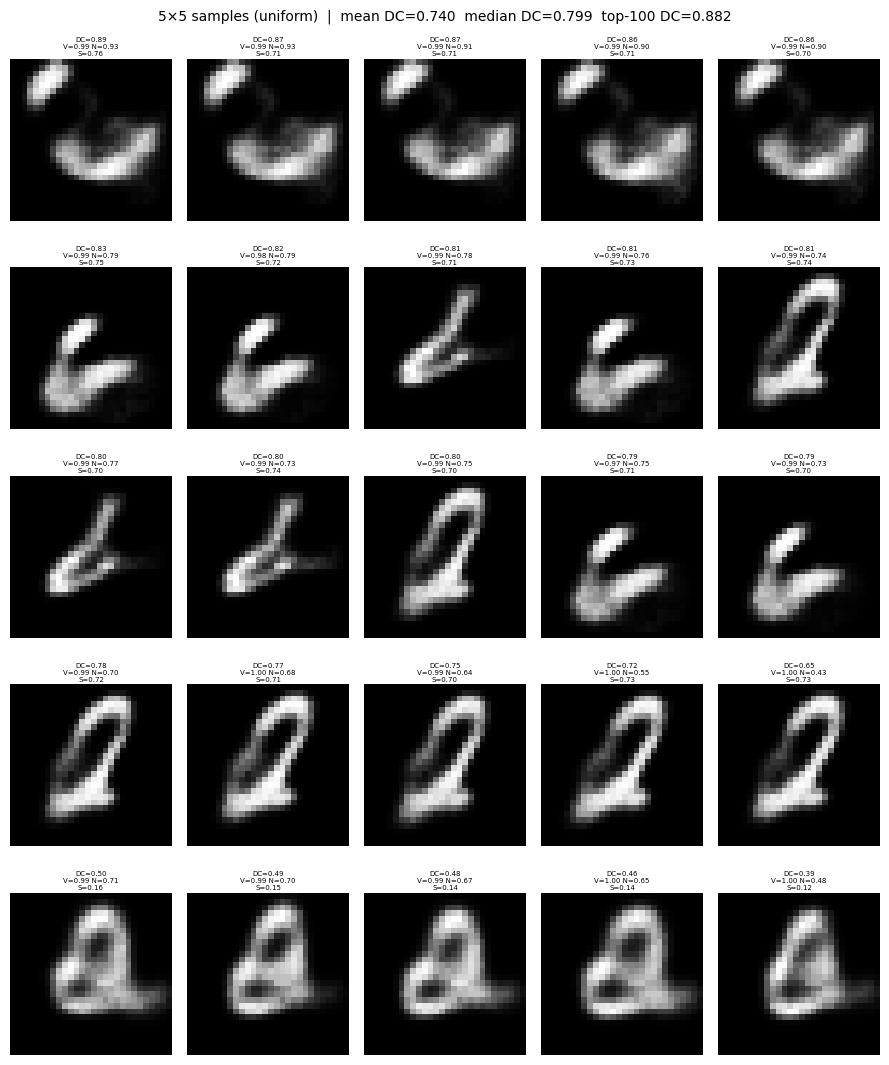

In [160]:
# ── uniform across DC distribution ────────────────────────────
plot_sample_grid(
    x_samples=x_samples_mix_c,
    z_samples=z_samples_mix_c,
    scores=scores_mix_c,
    digit_classifier=digit_clf,
    value_classifier=value_clf,
    sample_from="uniform",
    device=device,
    grid_size=5
)

In [161]:
save_dir = "model_samples"
os.makedirs(save_dir, exist_ok=True)

torch.save(x_samples_mix.cpu(),   os.path.join(save_dir, "base_multi_latent_optim.pt"))
torch.save(x_samples_mix_c.cpu(), os.path.join(save_dir, "creative_multi_latent_optim.pt"))

print(f"Saved → {save_dir}/base_multi_latent_optim.pt")
print(f"Saved → {save_dir}/creative_multi_latent_optim.pt")

Saved → model_samples/base_multi_latent_optim.pt
Saved → model_samples/creative_multi_latent_optim.pt
